In [1]:
import os 
import sys
import pandas as pd 
import numpy as np 

OR_LEARNING_PATH = os.path.join(os.getcwd().split('OR_learning')[0], 'OR_learning/')
sys.path.insert(0, os.path.join(OR_LEARNING_PATH, 'utils/'))

import plot_functions as pf
import color_function as cf 
import voxel_functions as vf 


In [2]:
import importlib 

importlib.reload(pf)
importlib.reload(cf)
importlib.reload(vf)

<module 'voxel_functions' from '/mnt/data2/Justice/OR_learning/utils/voxel_functions.py'>

### Evaluating hyperparameters

In [3]:
import numpy as np
import os

def is_val_loss_trending_down(val_losses, slope_threshold=-0.001):
    """Return True if val_loss has a downward slope over epochs."""
    epochs = np.arange(len(val_losses))
    slope = np.polyfit(epochs, val_losses, 1)[0]
    return slope < slope_threshold

def rank_models_across_runs(base_dir, slope_threshold = -0.001, min_best_epoch=2, auc_threshold=0.6, alpha=0.2):
    ranked_models = []

    for run_name in sorted(os.listdir(base_dir)):
        run_path = os.path.join(base_dir, run_name)
        if not os.path.isdir(run_path):
            continue

        try:
            # val_aucs = np.load(os.path.join(run_path, "val_aucs.npy")) # May have to change to val_accs.npy due to inconsistent naming previously
            val_aucs = np.load(os.path.join(run_path, "val_accs.npy"))
            val_losses = np.load(os.path.join(run_path, "val_losses.npy"))
            train_losses = np.load(os.path.join(run_path, "train_losses.npy"))
        except FileNotFoundError:
            print(f"Skipping {run_name}: missing file.")
            continue

        # Skip if val_loss not trending down
        epochs = np.arange(len(val_losses))
        slope = np.polyfit(epochs, val_losses, 1)[0]
        if not slope < slope_threshold:
            continue

        best_epoch = int(np.argmax(val_aucs))
        best_auc = val_aucs[best_epoch]
        best_val_loss = val_losses[best_epoch]
        train_loss = train_losses[best_epoch]

        # Skip if best epoch is too early
        if best_epoch < min_best_epoch:
            continue

        # Optional: skip weak AUCs
        if best_auc < auc_threshold:
            continue

        # Composite score: balance AUC with overfitting penalty
        # score = best_auc - alpha * (best_val_loss - train_loss)
        score = best_auc - alpha * (slope)

        ranked_models.append({
            "run_name": run_name,
            "score": score,
            "best_auc": best_auc,
            "best_val_loss": best_val_loss,
            "val_loss_slope": slope, 
            "train_loss": train_loss,
            "best_epoch": best_epoch
        })

    # Sort by score descending
    ranked_models = sorted(ranked_models, key=lambda x: x["score"], reverse=True)
    return ranked_models

In [8]:
""" 
Copy param.json to test_param to run longer 
"""

# manually picked model params 
# results = [results[i] for i in [0,1,3,4,5]]

# base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_binary/'
# base_dir      = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/param_sweep_cd32/'
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/param_sweep1/'


# top_param_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/top_params3_cd32'
top_param_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/top_params1/'

os.mkdir(os.path.join(top_param_dir))
os.mkdir(os.path.join(top_param_dir, 'params_json'))

import shutil
for i, r in enumerate(results[:4]): 
    shutil.copy(os.path.join(base_dir, r['run_name'], 'params.json'), 
                os.path.join(top_param_dir, 'params_json', f'{r['run_name']}_params.json'))
    
    
# Manually include cases 
# add_run_id = ['20250720_213430_ptAVG_lr0.0001_bs8_hd256_ks1_nl4_do0.7']

# for i, r in enumerate(add_run_id): 
#     shutil.copy(os.path.join(base_dir, r, 'params.json'), 
#                 os.path.join(base_dir, 'test_params', f'{r}_params.json'))
    
    

### ESM ChemClassification

In [4]:
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Chemclassify/top_params2/'

results = rank_models_across_runs(base_dir, slope_threshold=-1e-10, alpha=0, auc_threshold=0.10)

# Print top 5 models
for i, r in enumerate(results[:10]):
    print(f"Rank {i+1:<2}: {r['run_name']:<60} | AUC: {r['best_auc']:.4f} | ValLoss: {r['best_val_loss']:<.4} | ValLossSlope: {r['val_loss_slope']:<.4} | Epoch: {r['best_epoch']}")

Rank 1 : 20251007_130024_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue | AUC: 0.4374 | ValLoss: 0.06586 | ValLossSlope: -0.001017 | Epoch: 69
Rank 2 : 20251007_132347_lr0.0001_bs8_hd16_ks5_nl1_do0.0_ptAVG_an0_am0_anum3_vt0.5_mlTrue | AUC: 0.4292 | ValLoss: 0.07062 | ValLossSlope: -0.001416 | Epoch: 76
Rank 3 : 20251007_130644_lr1e-05_bs8_hd16_ks5_nl1_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue | AUC: 0.3926 | ValLoss: 0.09714 | ValLossSlope: -0.002558 | Epoch: 113
Rank 4 : 20251007_131650_lr0.0001_bs4_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.5_mlTrue | AUC: 0.2850 | ValLoss: 0.08449 | ValLossSlope: -0.001229 | Epoch: 64


/tmp/ipykernel_87980/1266911116.py:118: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(frameon=False)
/tmp/ipykernel_87980/1266911116.py:118: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(frameon=False)
/tmp/ipykernel_87980/1266911116.py:118: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(frameon=False)
/tmp/ipykernel_87980/1266911116.py:118: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(frameon=False)


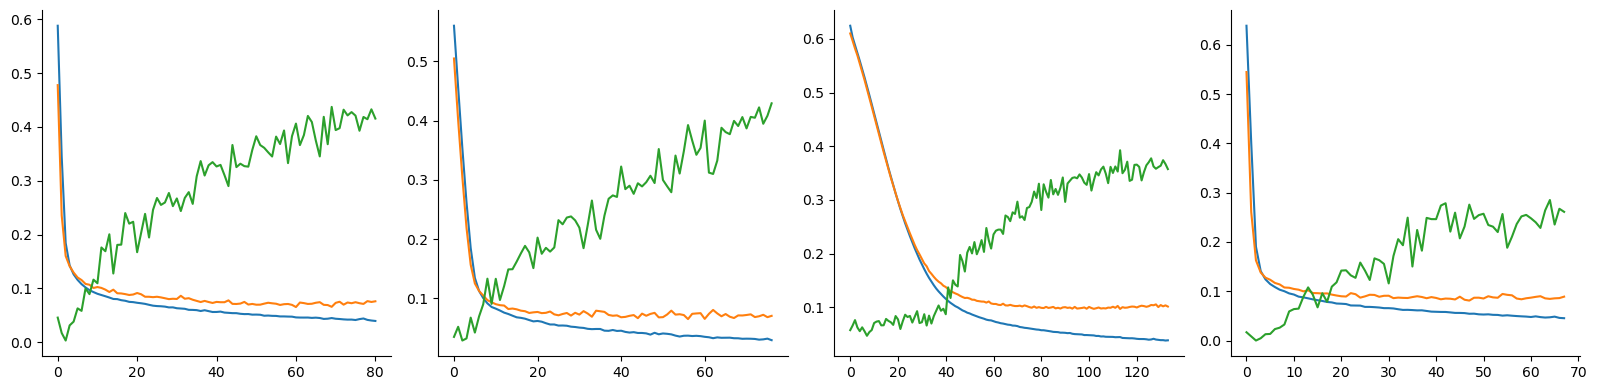

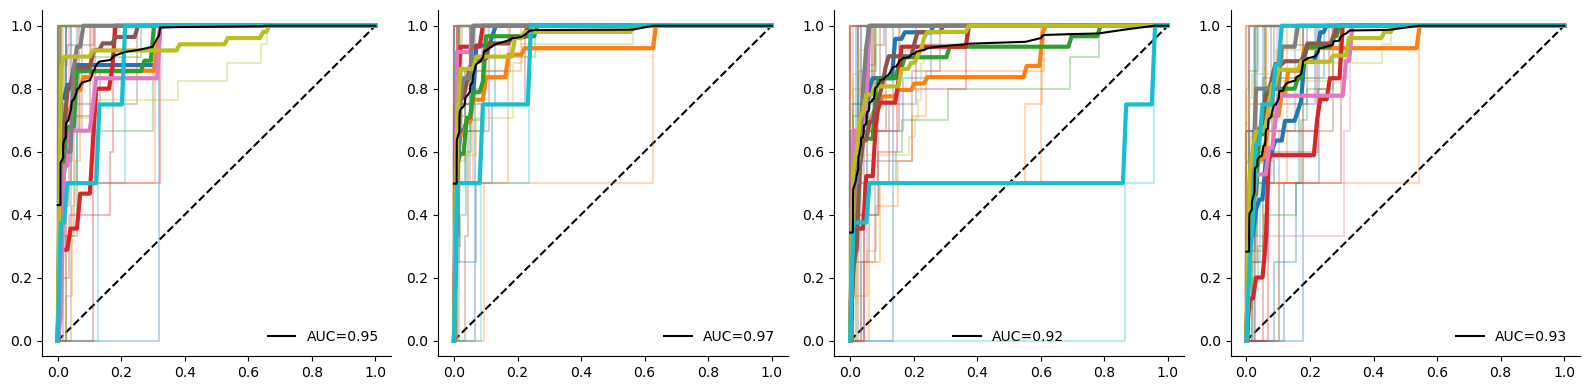

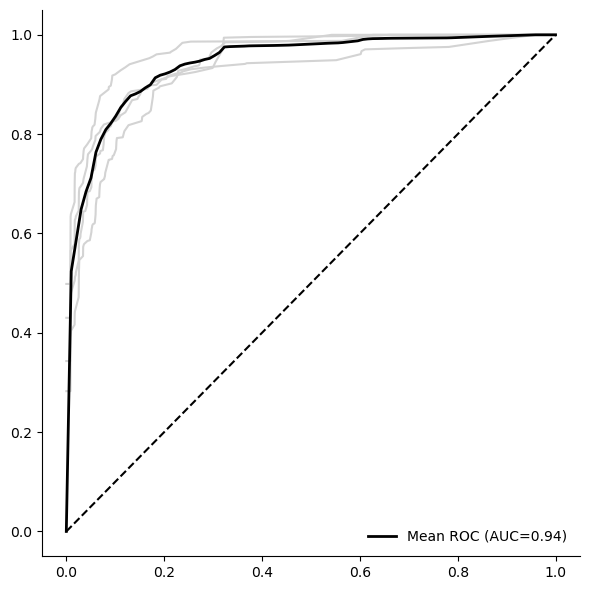

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.preprocessing import label_binarize

ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')] # Subset for concentration in percentages 
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()

# Dropping 'Others'AssertionError
ps6_df = ps6_df[ps6_df.odor_category != 'Others']


ODORS = sorted(ps6_df.odor.unique())
ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODORS)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODORS)}
NUM_ODORS = len(ODORS)

# Build mapping from odor to category and category to color
odor_to_category = dict(zip(ps6_df.odor, ps6_df.odor_category))
odor_color = cf.distinct_colors(ps6_df.odor_category.unique(), category='tab10')

# Numbers of model to plot 
plot_result = results[:4]
figsize_per_plot = [4,4]

n = len(plot_result)
ncols = 4
nrows = int(np.ceil(n / ncols))
figsize = (figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)

fig_curve, axes_curve = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_curve = np.array(axes_curve).reshape(-1)

fig_roc_ind, axes_roc_ind = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_roc_ind = np.array(axes_roc_ind).reshape(-1)

fig_roc, axes_roc = plt.subplots(figsize = (6,6))

# Prepare common FPR grid for averaging
overall_mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

# Dict to store category-level curves
category_curves_all = {cat: [] for cat in ps6_df.odor_category.unique()}

for plot_i, r in enumerate(plot_result):
    # Load data
    train_losses = np.load(os.path.join(base_dir, r['run_name'], 'train_losses.npy'))
    val_losses   = np.load(os.path.join(base_dir, r['run_name'], 'val_losses.npy'))
    val_aucs     = np.load(os.path.join(base_dir, r['run_name'], 'val_accs.npy'))
    val_labels = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    # --- Loss plots ---
    ax1 = axes_curve[plot_i]
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses, label="Val Loss")
    ax1.plot(val_aucs, label="Val AUC")
    
    y_true_bin = val_labels
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    
    # Compute ROC per odor
    for i in range(NUM_ODORS):
        if np.sum(y_true_bin[:, i]) > 0:
            fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
            roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
    
    # Macro-average ROC for this run
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in roc_auc_dict]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in roc_auc_dict:
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= len(roc_auc_dict)
    roc_auc_macro = auc(all_fpr, mean_tpr)
    
    # --- Plot individual ROC per odor with category colors ---
    ax3 = axes_roc_ind[plot_i]
    ax3.plot([0, 1], [0, 1], 'k--')
    
    category_curves = {cat: [] for cat in ps6_df.odor_category.unique()}
    
    for i, _odor in enumerate(ODORS):
        if np.sum(y_true_bin[:, i]) == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
        roc_auc_i = auc(fpr, tpr)
        odor_cat = odor_to_category[_odor]
        color = odor_color[odor_cat]

        # Individual odor line (faded)
        ax3.plot(fpr, tpr, color=color, alpha=0.3)
        
        # Collect for category averaging
        category_curves[odor_cat].append((fpr, tpr))
        category_curves_all[odor_cat].append((fpr, tpr))
    
    # Plot category-averaged ROC for this run
    for cat, curves in category_curves.items():
        if not curves:
            continue
        mean_fpr = np.linspace(0, 1, 100)
        tprs_cat = []
        for fpr, tpr in curves:
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs_cat.append(tpr_interp)
        mean_tpr_cat = np.mean(tprs_cat, axis=0)
        mean_tpr_cat[-1] = 1.0
        mean_auc_cat = auc(mean_fpr, mean_tpr_cat)
        ax3.plot(mean_fpr, mean_tpr_cat, color=odor_color[cat], lw=3,
                #  label=f"{cat} Avg (AUC={mean_auc_cat:.2f})"
                 )
    
    ax3.legend(frameon=False)

    # --- For overall mean ROC ---
    tpr_interp = np.interp(overall_mean_fpr, all_fpr, mean_tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
    aucs.append(roc_auc_macro)
    
    axes_roc.plot(all_fpr, mean_tpr, c='#D3D3D3')
    ax3.plot(all_fpr, mean_tpr, c='black', label=f"AUC={roc_auc_macro:.2f}")
    ax3.legend(frameon=False)

# --- Plot overall mean ROC ---
overall_mean_tpr = np.mean(tprs, axis=0)
overall_mean_tpr[-1] = 1.0
overall_mean_auc = np.mean(aucs)
axes_roc.plot(overall_mean_fpr, overall_mean_tpr, color='black', lw=2,
              label=f"Mean ROC (AUC={overall_mean_auc:.2f})")
axes_roc.plot([0, 1], [0, 1], 'k--') 
axes_roc.legend(frameon=False)

# --- Clean and show figures ---
fig_curve = pf.plt_clean_axes(fig_curve)
fig_curve.tight_layout()
fig_curve.show()

fig_roc_ind = pf.plt_clean_axes(fig_roc_ind)
fig_roc_ind.tight_layout()
fig_roc_ind.show()

fig_roc = pf.plt_clean_axes(fig_roc)
fig_roc.tight_layout()
fig_roc.show()

ValueError: fp and xp are not of the same length.

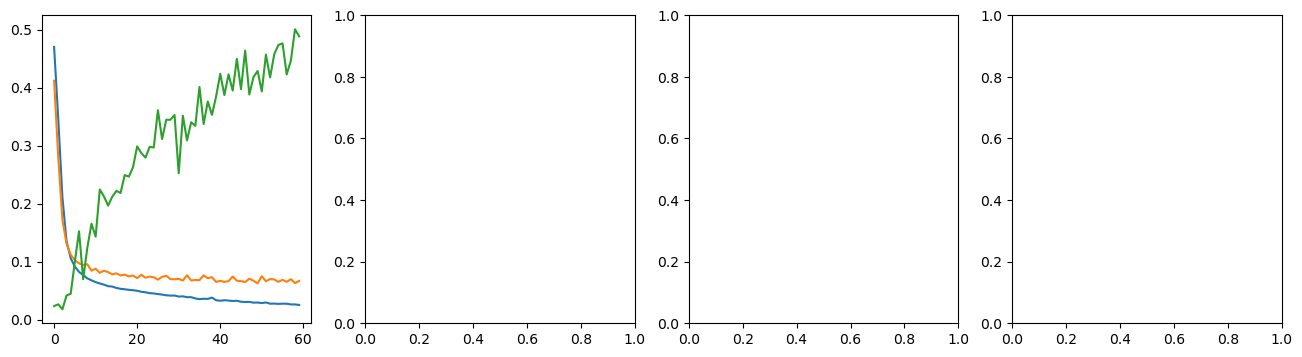

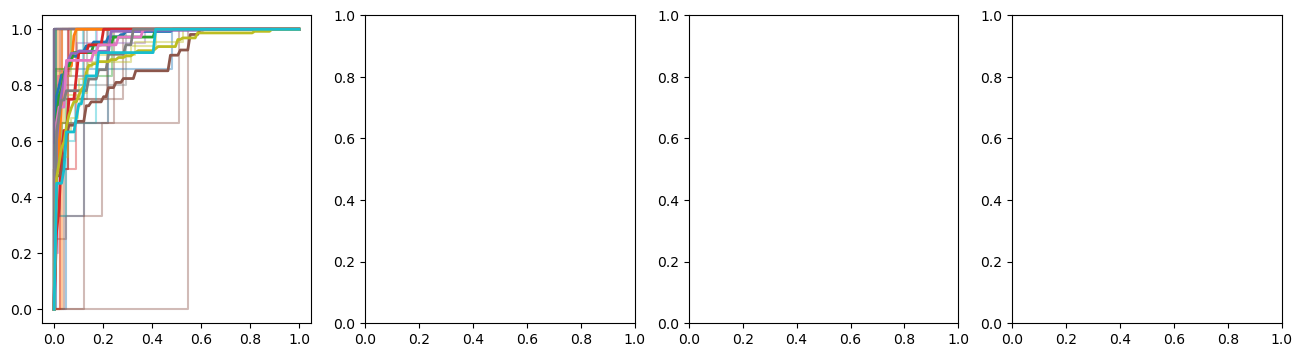

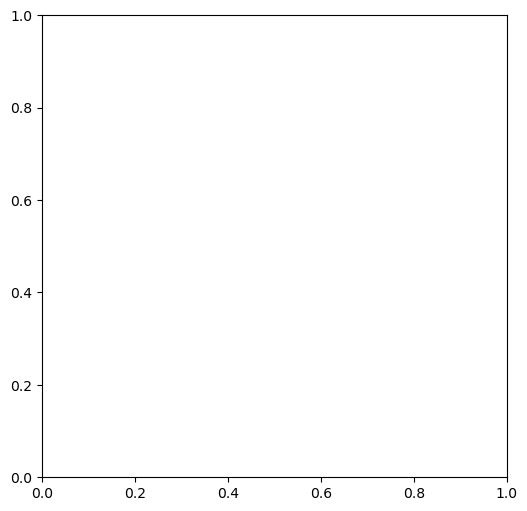

In [37]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.preprocessing import label_binarize



ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')] # Subset for concentration in percentages 
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()


ODORS = sorted(ps6_df.odor.unique())
ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
ODOR_TO_IDX = {cat: i for i, cat in enumerate(ODORS)}
IDX_TO_ODOR = {i: cat for i, cat in enumerate(ODORS)}
NUM_ODORS = len(ODORS)

odor_color = cf.distinct_colors(ps6_df.odor_category.unique(), category='tab10')

# Numbers of model to plot 
plot_result = results[:4]
figsize_per_plot = [4,4]

n = len(plot_result)
ncols = 4
nrows = int(np.ceil(n / ncols))
figsize = (figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)

fig_curve, axes_curve = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_curve = np.array(axes_curve).reshape(-1)

fig_roc_ind, axes_roc_ind = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_roc_ind = np.array(axes_roc_ind).reshape(-1)

fig_roc, axes_roc = plt.subplots(figsize = (6,6))

# Prepare common FPR grid for averaging
overall_mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
for plot_i, r in enumerate(plot_result):
    # Plot curves
    train_losses = np.load(os.path.join(base_dir, r['run_name'], 'train_losses.npy'))
    val_losses   = np.load(os.path.join(base_dir, r['run_name'], 'val_losses.npy'))
    val_aucs     = np.load(os.path.join(base_dir, r['run_name'], 'val_accs.npy'))
    
    # Plot roc
    val_labels = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    
    ax1 = axes_curve[plot_i]
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses, label="Val Loss")
    ax1.plot(val_aucs, label="Val AUC")
    
    y_true_bin = val_labels
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    for i in range(NUM_ODORS):
        if np.sum(y_true_bin[:, i]) > 0:  # skip empty classes
            fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
            roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in roc_auc_dict]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in roc_auc_dict:
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= len(roc_auc_dict)
    roc_auc_macro = auc(all_fpr, mean_tpr)
    
    # for i, _odor in enumerate(ODORS):
    #     if np.sum(y_true_bin[:, i]) == 0:
    #         continue
    #     fpr, tpr, _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
    #     roc_auc_i = auc(fpr, tpr)
    
    #     ax3 = axes_roc_ind[plot_i]
    #     ax3.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
    #     # ax3.plot(fpr, tpr, label=f"{_odor} (AUC={roc_auc_i:.2f})")
    #     ax3.plot(fpr, tpr)
    #     ax3.legend(frameon=False)
    
    ax3 = axes_roc_ind[plot_i]
    for i, _odor in enumerate(ODORS):
        if np.sum(y_true_bin[:, i]) == 0:
            continue
        
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
        roc_auc_i = auc(fpr, tpr)

        odor_cat = odor_to_category[_odor]
        color = odor_color.get(odor_cat)

        # --- Individual odor curve (category-colored) ---
        ax3.plot(fpr, tpr, color=color, alpha=0.4, 
                label=f"{_odor} (AUC={roc_auc_i:.2f})")

        # Store for category averaging
        category_curves[odor_cat].append((fpr, tpr))

    # --- Category-averaged curves ---
    for cat, curves in category_curves.items():
        if not curves:
            continue
        # Interpolate to the same grid
        mean_fpr = np.linspace(0, 1, 100)
        tprs = []
        for fpr, tpr in curves:
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)

        ax3.plot(mean_fpr, mean_tpr, color=odor_color.get(cat), lw=2,
                label=f"{cat} Avg (AUC={mean_auc:.2f})")

    
    # Interpolate TPR to the mean FPR grid
    tpr_interp = np.interp(overall_mean_fpr, all_fpr, mean_tpr)
    tpr_interp[0] = 0.0  # ensure start at 0
    tprs.append(tpr_interp)
    aucs.append(roc_auc_macro)
    
    axes_roc.plot(all_fpr, mean_tpr, c='#D3D3D3')
    
    ax3.plot(all_fpr, mean_tpr, c='black', label=f"AUC={np.mean(roc_auc_macro):.2f}")
    ax3.legend(frameon=False)
    

fig_curve = pf.plt_clean_axes(fig_curve)
fig_curve.tight_layout()
fig_curve.show()

# fig_conf = pf.plt_clean_axes(fig_conf)
# fig_conf.tight_layout()
# fig_conf.show()

fig_roc_ind = pf.plt_clean_axes(fig_roc_ind)
fig_roc_ind.tight_layout()
fig_roc_ind.show()

# Average curve
overall_mean_tpr = np.mean(tprs, axis=0)
overall_mean_tpr[-1] = 1.0  # ensure end at 1
overall_mean_auc = np.mean(aucs)
axes_roc.plot(overall_mean_fpr, overall_mean_tpr, color='black', lw=2,
              label=f"Mean ROC (AUC = {overall_mean_auc:.2f})")
axes_roc.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
axes_roc.legend(frameon=False)
fig_roc = pf.plt_clean_axes(fig_roc)
fig_roc.tight_layout()
fig_roc.show()



### ESM Odor classify

In [5]:
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_Odorclassify/param_sweep1/'

results = rank_models_across_runs(base_dir, slope_threshold=-1e-10, alpha=0, auc_threshold=0.10)

# Print top 5 models
for i, r in enumerate(results[:10]):
    print(f"Rank {i+1:<2}: {r['run_name']:<60} | AUC: {r['best_auc']:.4f} | ValLoss: {r['best_val_loss']:<.4} | ValLossSlope: {r['val_loss_slope']:<.4} | Epoch: {r['best_epoch']}")

Skipping 20250911_190231_lr1e-05_bs4_hd8_ks5_nl2_do0.2_ptAVG_an0_am0_anum3_vt0.5_mlTrue: missing file.
Rank 1 : 20250911_172304_lr0.0001_bs8_hd16_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.5_mlTrue | AUC: 0.8617 | ValLoss: 0.1246 | ValLossSlope: -0.003055 | Epoch: 42
Rank 2 : 20250911_175246_lr0.0001_bs4_hd16_ks5_nl1_do0.0_ptAVG_an0_am0_anum3_vt0.5_mlTrue | AUC: 0.8588 | ValLoss: 0.1252 | ValLossSlope: -0.002282 | Epoch: 47
Rank 3 : 20250911_184516_lr0.0001_bs8_hd16_ks5_nl2_do0.2_ptAVG_an0_am0_anum3_vt0.3_mlTrue | AUC: 0.8425 | ValLoss: 0.1119 | ValLossSlope: -0.002631 | Epoch: 64
Rank 4 : 20250911_185736_lr0.0001_bs4_hd8_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue | AUC: 0.7813 | ValLoss: 0.1489 | ValLossSlope: -0.003159 | Epoch: 50
Rank 5 : 20250911_185140_lr0.0001_bs8_hd8_ks5_nl2_do0.2_ptAVG_an0_am0_anum3_vt0.3_mlTrue | AUC: 0.7479 | ValLoss: 0.1401 | ValLossSlope: -0.004097 | Epoch: 54
Rank 6 : 20250911_170820_lr1e-05_bs4_hd8_ks5_nl2_do0.0_ptAVG_an0_am0_anum3_vt0.3_mlTrue | AUC: 0.74

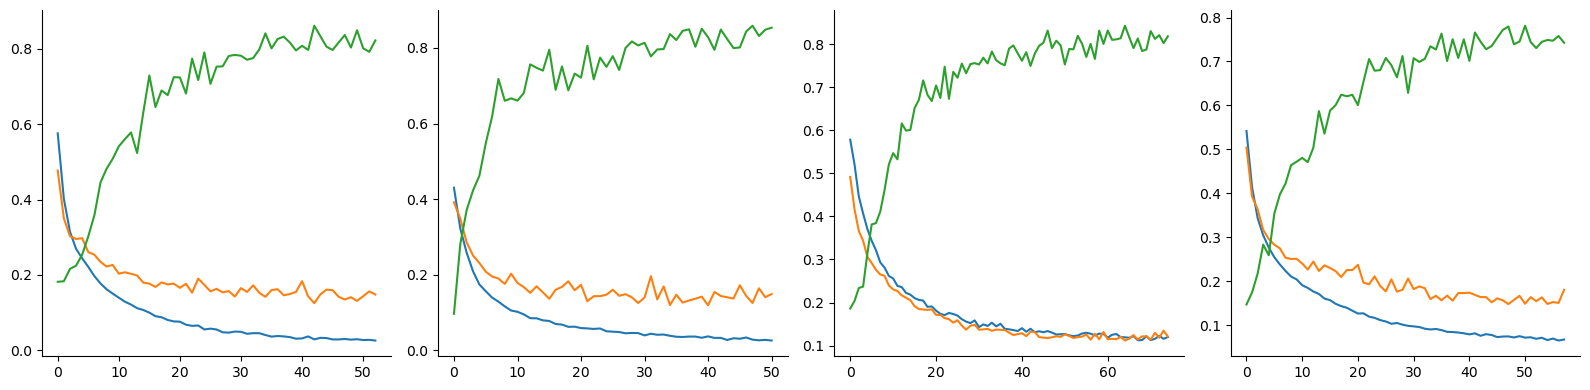

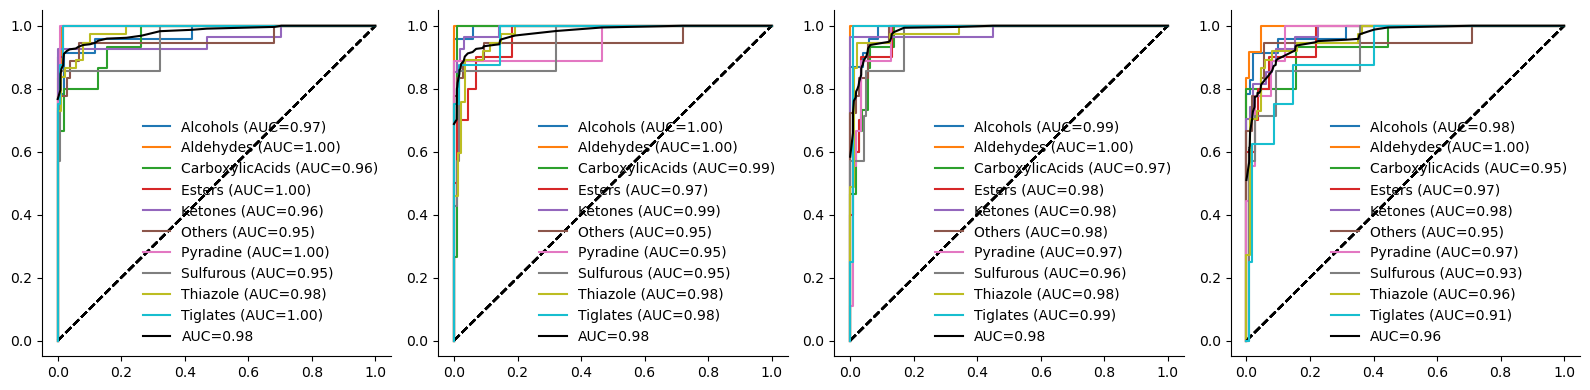

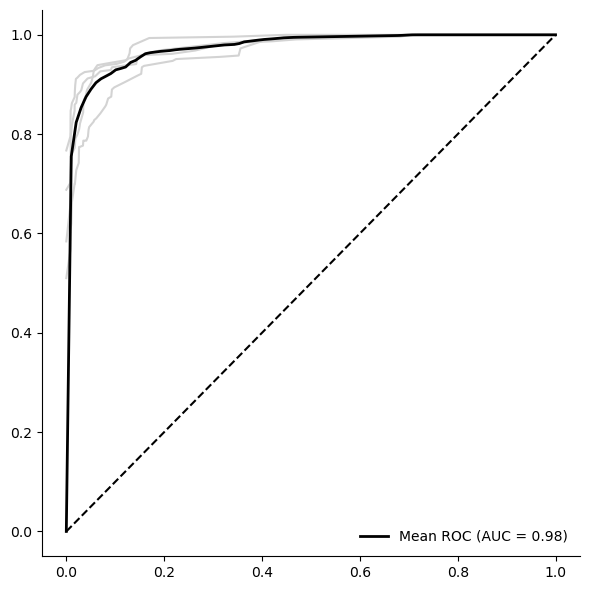

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.preprocessing import label_binarize



ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')] # Subset for concentration in percentages 
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()


ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

plot_result = results[:4]


figsize_per_plot = [4,4]

n = len(plot_result)
ncols = 4
nrows = int(np.ceil(n / ncols))
figsize = (figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)

fig_curve, axes_curve = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_curve = np.array(axes_curve).reshape(-1)

fig_roc_ind, axes_roc_ind = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_roc_ind = np.array(axes_roc_ind).reshape(-1)

fig_roc, axes_roc = plt.subplots(figsize = (6,6))

# Prepare common FPR grid for averaging
overall_mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
for plot_i, r in enumerate(plot_result):
    # Plot curves
    train_losses = np.load(os.path.join(base_dir, r['run_name'], 'train_losses.npy'))
    val_losses   = np.load(os.path.join(base_dir, r['run_name'], 'val_losses.npy'))
    val_aucs     = np.load(os.path.join(base_dir, r['run_name'], 'val_accs.npy'))
    
    # Plot roc
    val_labels = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    
    ax1 = axes_curve[plot_i]
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses, label="Val Loss")
    ax1.plot(val_aucs, label="Val AUC")
    
    y_true_bin = val_labels
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    for i in range(NUM_ODOR_CLASSES):
        if np.sum(y_true_bin[:, i]) > 0:  # skip empty classes
            fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
            roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in roc_auc_dict]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in roc_auc_dict:
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= len(roc_auc_dict)
    roc_auc_macro = auc(all_fpr, mean_tpr)
    
    for i, _odor in enumerate(ODOR_CATEGORIES):
        if np.sum(y_true_bin[:, i]) == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
        roc_auc_i = auc(fpr, tpr)
    
        ax3 = axes_roc_ind[plot_i]
        ax3.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
        ax3.plot(fpr, tpr, label=f"{_odor} (AUC={roc_auc_i:.2f})")
        # ax3.plot(fpr, tpr)
        ax3.legend(frameon=False)

    
    # Interpolate TPR to the mean FPR grid
    tpr_interp = np.interp(overall_mean_fpr, all_fpr, mean_tpr)
    tpr_interp[0] = 0.0  # ensure start at 0
    tprs.append(tpr_interp)
    aucs.append(roc_auc_macro)
    
    axes_roc.plot(all_fpr, mean_tpr, c='#D3D3D3')
    
    ax3.plot(all_fpr, mean_tpr, c='black', label=f"AUC={np.mean(roc_auc_macro):.2f}")
    ax3.legend(frameon=False)
    

fig_curve = pf.plt_clean_axes(fig_curve)
fig_curve.tight_layout()
fig_curve.show()

# fig_conf = pf.plt_clean_axes(fig_conf)
# fig_conf.tight_layout()
# fig_conf.show()

fig_roc_ind = pf.plt_clean_axes(fig_roc_ind)
fig_roc_ind.tight_layout()
fig_roc_ind.show()

# Average curve
overall_mean_tpr = np.mean(tprs, axis=0)
overall_mean_tpr[-1] = 1.0  # ensure end at 1
overall_mean_auc = np.mean(aucs)
axes_roc.plot(overall_mean_fpr, overall_mean_tpr, color='black', lw=2,
              label=f"Mean ROC (AUC = {overall_mean_auc:.2f})")
axes_roc.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
axes_roc.legend(frameon=False)
fig_roc = pf.plt_clean_axes(fig_roc)
fig_roc.tight_layout()
fig_roc.show()



### AA Odor classify

#### Multi-label

In [ ]:
# base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/top_params2/'
# base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/param_sweep3/'
# base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/top_params2_cd38/'
# base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/param_sweep_cd30/'
# base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/top_params3_cd35/'
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_Odorclassify/param_sweep_cd32/'

results = rank_models_across_runs(base_dir, slope_threshold=-1e-10, alpha=0, auc_threshold=0.10)

# Print top 5 models
for i, r in enumerate(results[:10]):
    print(f"Rank {i+1:<2}: {r['run_name']:<60} | AUC: {r['best_auc']:.4f} | ValLoss: {r['best_val_loss']:<.4} | ValLossSlope: {r['val_loss_slope']:<.4} | Epoch: {r['best_epoch']}")

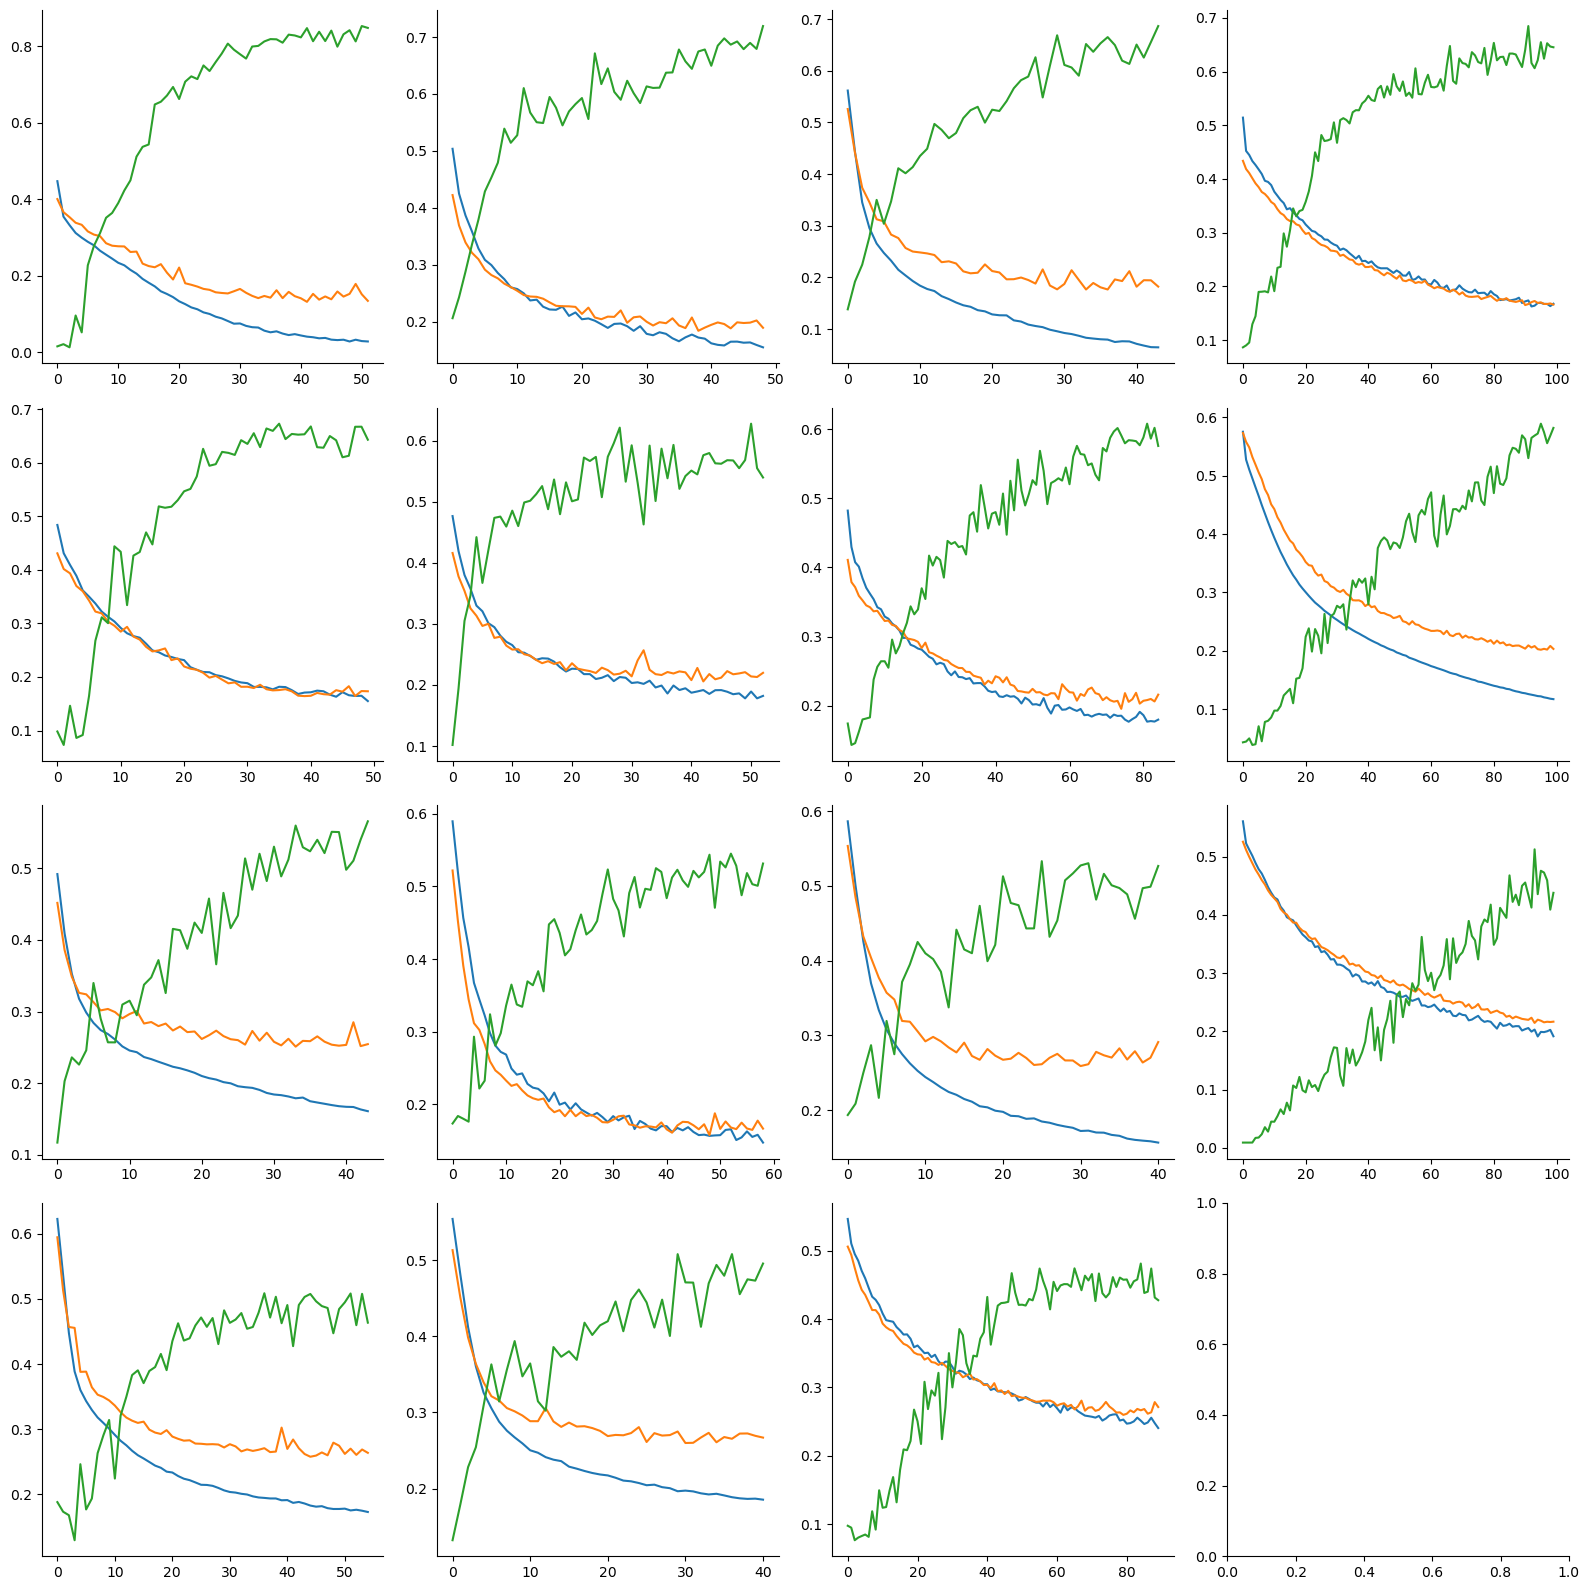

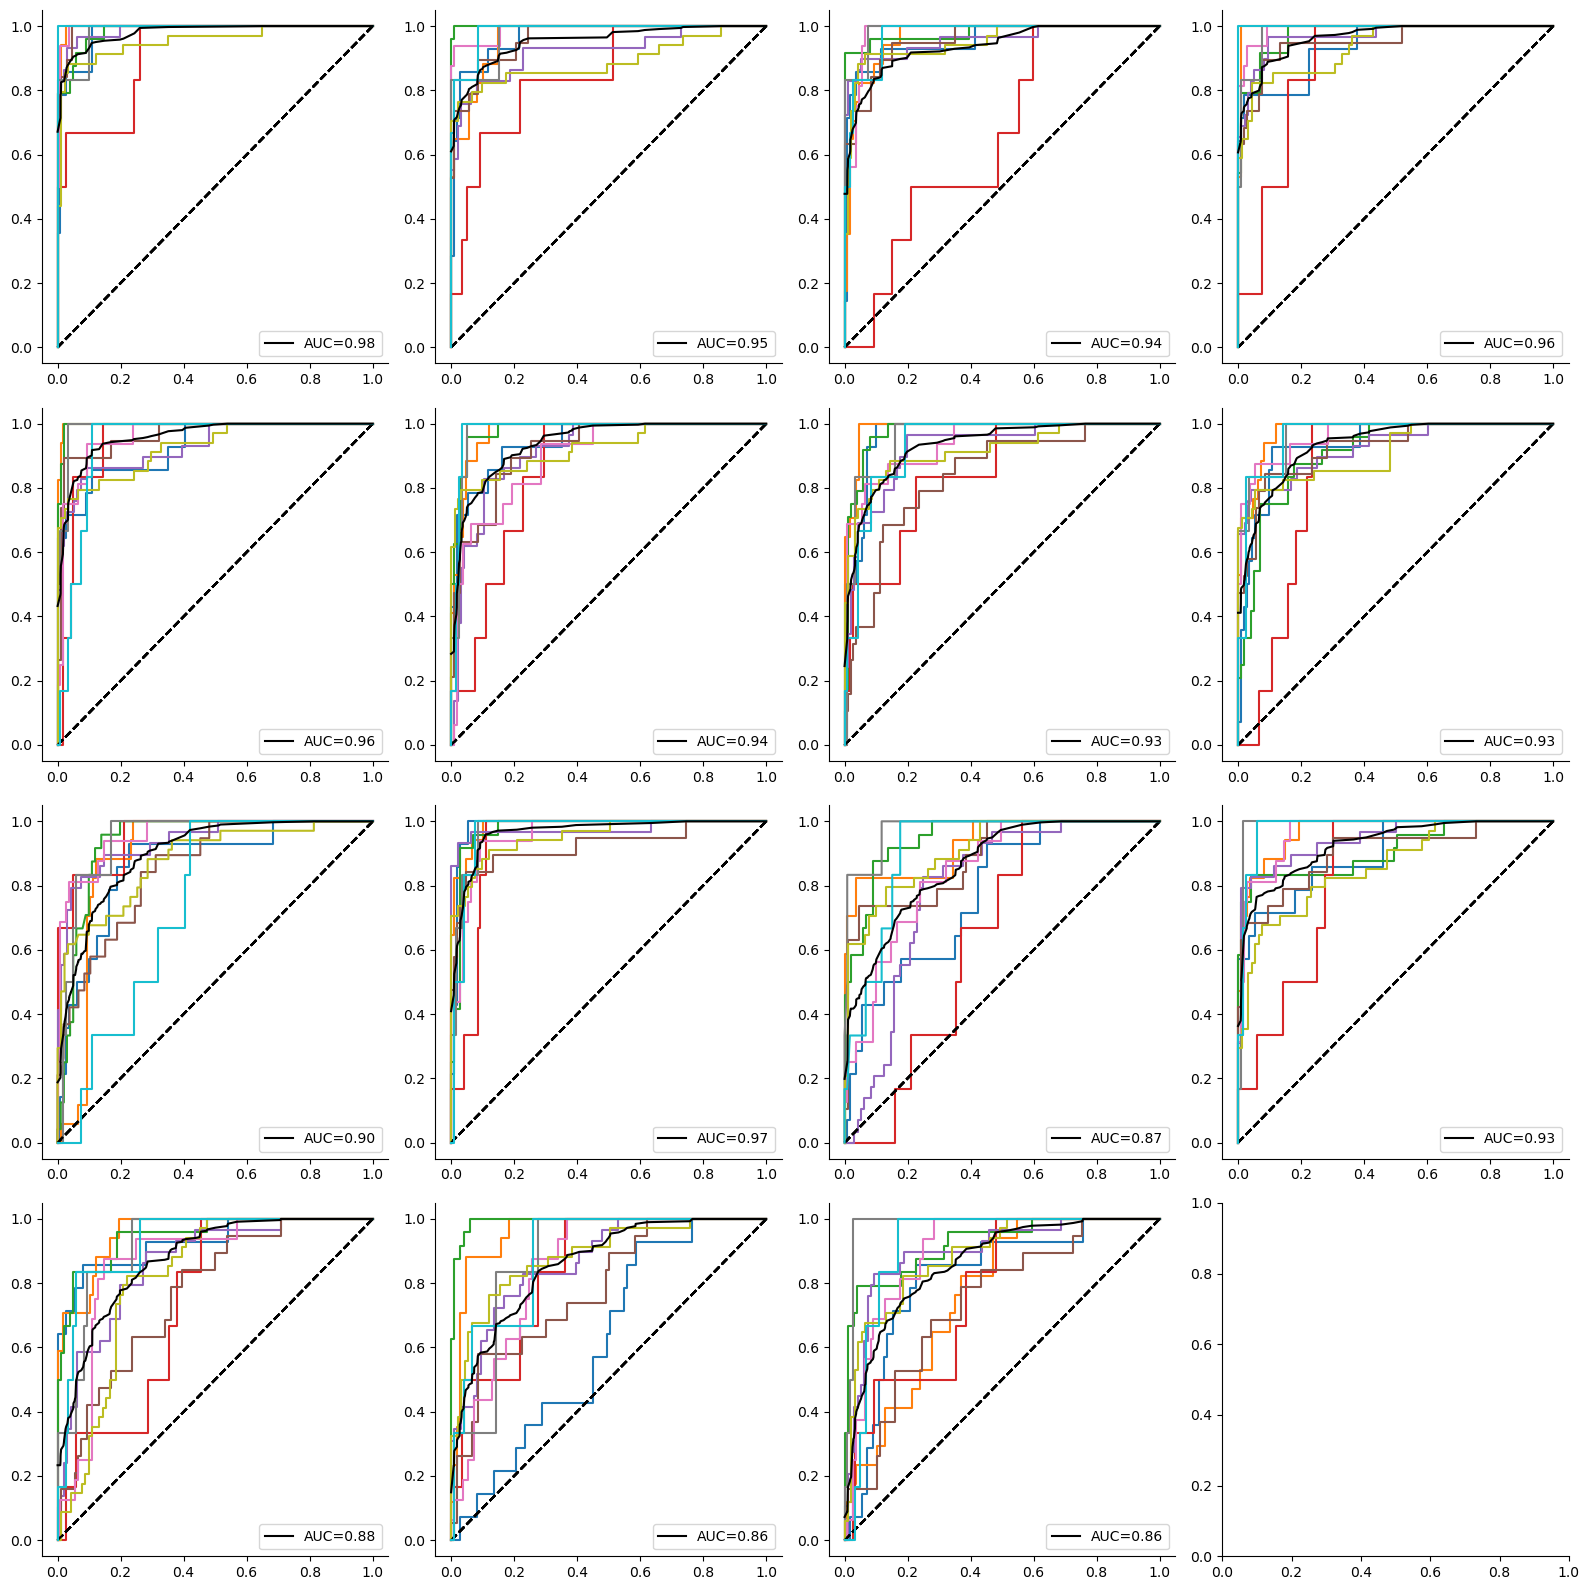

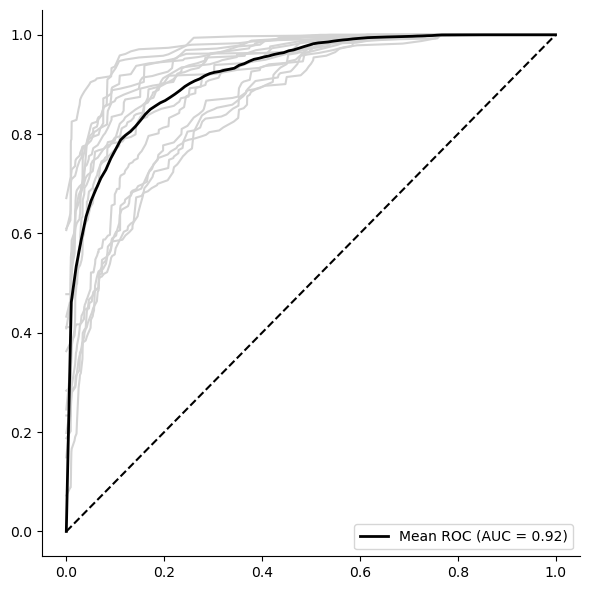

In [59]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.preprocessing import label_binarize



ps6_df = pd.read_csv('/mnt/data2/Justice/OR_learning/files/pS6IP/pS6IP_MASTER_HL_Annotated_2025.csv', index_col = 0) 
ps6_df = ps6_df[ps6_df.concentration.str.contains('p')] # Subset for concentration in percentages 
ps6_df = ps6_df.sort_values(['Family', 'DL_OR', 'odor_category', 'odor', 'concentration', 'FDR', 'activation_zscore']).dropna()


ODOR_CATEGORIES = sorted(ps6_df.odor_category.unique())
NUM_ODOR_CLASSES = len(ODOR_CATEGORIES)

plot_result = results[:15]


figsize_per_plot = [4,4]

n = len(plot_result)
ncols = 4
nrows = int(np.ceil(n / ncols))
figsize = (figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)

fig_curve, axes_curve = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_curve = np.array(axes_curve).reshape(-1)

# fig_conf, axes_conf = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
# axes_conf = np.array(axes_conf).reshape(-1)

fig_roc_ind, axes_roc_ind = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_roc_ind = np.array(axes_roc_ind).reshape(-1)

fig_roc, axes_roc = plt.subplots(figsize = (6,6))

# Prepare common FPR grid for averaging
overall_mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
for plot_i, r in enumerate(plot_result):
    # Plot curves
    train_losses = np.load(os.path.join(base_dir, r['run_name'], 'train_losses.npy'))
    val_losses   = np.load(os.path.join(base_dir, r['run_name'], 'val_losses.npy'))
    val_aucs     = np.load(os.path.join(base_dir, r['run_name'], 'val_accs.npy'))
    
    # Plot roc
    val_labels = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    
    ax1 = axes_curve[plot_i]
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses, label="Val Loss")
    ax1.plot(val_aucs, label="Val AUC")
    
    # Plot matrices
    # conf = confusion_matrix(val_labels, np.argmax(val_probs, axis=1))
    # # annotations = np.where(conf != 0, conf.astype(str), '')
    # ax2 = axes_conf[i]
    # sns.heatmap(conf, 
    #             annot=np.where(conf != 0, conf, ''), fmt='', # don't annotate 0 
    #             square=True, 
    #             cbar=False,
    #             cmap='Blues', 
    #             ax = ax2,
    #             xticklabels=ODOR_CATEGORIES
    #             # yticklabels=FAMILIES
    #             )
    
    y_true_bin = val_labels
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    for i in range(NUM_ODOR_CLASSES):
        if np.sum(y_true_bin[:, i]) > 0:  # skip empty classes
            fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
            roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in roc_auc_dict]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in roc_auc_dict:
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= len(roc_auc_dict)
    roc_auc_macro = auc(all_fpr, mean_tpr)
    
    for i, _odor in enumerate(ODOR_CATEGORIES):
        if np.sum(y_true_bin[:, i]) == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], val_probs[:, i])
        roc_auc_i = auc(fpr, tpr)
    
        ax3 = axes_roc_ind[plot_i]
        ax3.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
        # ax3.plot(fpr, tpr, label=f"{_odor} (AUC={roc_auc_i:.2f})")
        ax3.plot(fpr, tpr)
        # ax3.legend()

        
    # y_true_bin = label_binarize(val_labels, classes=range(NUM_ODOR_CLASSES))  # one-hot
    # val_preds_class = np.argmax(val_probs, axis=1)
    # y_correct = (val_preds_class == val_labels).astype(int)  # 1 if correct, 0 if incorrect
    # y_score = np.max(val_probs, axis=1)  # confidence of predicted class

    # fpr, tpr, _ = roc_curve(y_correct, y_score)
    # roc_auc = auc(fpr, tpr)
    
    # Interpolate TPR to the mean FPR grid
    tpr_interp = np.interp(overall_mean_fpr, all_fpr, mean_tpr)
    tpr_interp[0] = 0.0  # ensure start at 0
    tprs.append(tpr_interp)
    aucs.append(roc_auc_macro)
    
    axes_roc.plot(all_fpr, mean_tpr, c='#D3D3D3')
    
    ax3.plot(all_fpr, mean_tpr, c='black', label=f"AUC={np.mean(roc_auc_macro):.2f}")
    ax3.legend()
    

fig_curve = pf.plt_clean_axes(fig_curve)
fig_curve.tight_layout()
fig_curve.show()

# fig_conf = pf.plt_clean_axes(fig_conf)
# fig_conf.tight_layout()
# fig_conf.show()

fig_roc_ind = pf.plt_clean_axes(fig_roc_ind)
fig_roc_ind.tight_layout()
fig_roc_ind.show()

# Average curve
overall_mean_tpr = np.mean(tprs, axis=0)
overall_mean_tpr[-1] = 1.0  # ensure end at 1
overall_mean_auc = np.mean(aucs)
axes_roc.plot(overall_mean_fpr, overall_mean_tpr, color='black', lw=2,
              label=f"Mean ROC (AUC = {overall_mean_auc:.2f})")
axes_roc.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
axes_roc.legend()
fig_roc = pf.plt_clean_axes(fig_roc)
fig_roc.tight_layout()
fig_roc.show()



### AA OR classify

In [17]:
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_ORclassify/param_sweep2/'
results = rank_models_across_runs(base_dir, slope_threshold=np.inf, alpha=0.1, auc_threshold=0.60)

# Print top 5 models
for i, r in enumerate(results[:10]):
    print(f"Rank {i+1:<2}: {r['run_name']:<60} | AUC: {r['best_auc']:.4f} | ValLoss: {r['best_val_loss']:<.4} | ValLossSlope: {r['val_loss_slope']:<.4} | Epoch: {r['best_epoch']}")

Rank 1 : 20250828_211633_lr0.001_bs8_hd32_ks3_nl2_do0.2_ptMAX_agmntFalse | AUC: 0.9964 | ValLoss: 0.01243 | ValLossSlope: -0.004527 | Epoch: 25
Rank 2 : 20250828_142122_lr0.001_bs8_hd32_ks5_nl2_do0.2_ptMAX_agmntTrue | AUC: 0.9928 | ValLoss: 0.04549 | ValLossSlope: -0.003218 | Epoch: 24
Rank 3 : 20250828_164051_lr0.001_bs8_hd16_ks3_nl2_do0.0_ptMAX_agmntFalse | AUC: 0.9892 | ValLoss: 0.04987 | ValLossSlope: -0.00391 | Epoch: 11
Rank 4 : 20250828_145031_lr0.001_bs8_hd32_ks5_nl1_do0.2_ptMAX_agmntFalse | AUC: 0.9892 | ValLoss: 0.04008 | ValLossSlope: -0.003106 | Epoch: 14
Rank 5 : 20250828_173526_lr0.001_bs16_hd16_ks5_nl2_do0.2_ptMAX_agmntTrue | AUC: 0.9856 | ValLoss: 0.05541 | ValLossSlope: -0.008108 | Epoch: 21
Rank 6 : 20250828_182233_lr0.001_bs16_hd32_ks3_nl2_do0.0_ptAVG_agmntTrue | AUC: 0.9856 | ValLoss: 0.06562 | ValLossSlope: -0.006452 | Epoch: 24
Rank 7 : 20250828_180439_lr0.001_bs16_hd32_ks5_nl1_do0.0_ptAVG_agmntTrue | AUC: 0.9856 | ValLoss: 0.09543 | ValLossSlope: 0.0003917 | Epoc

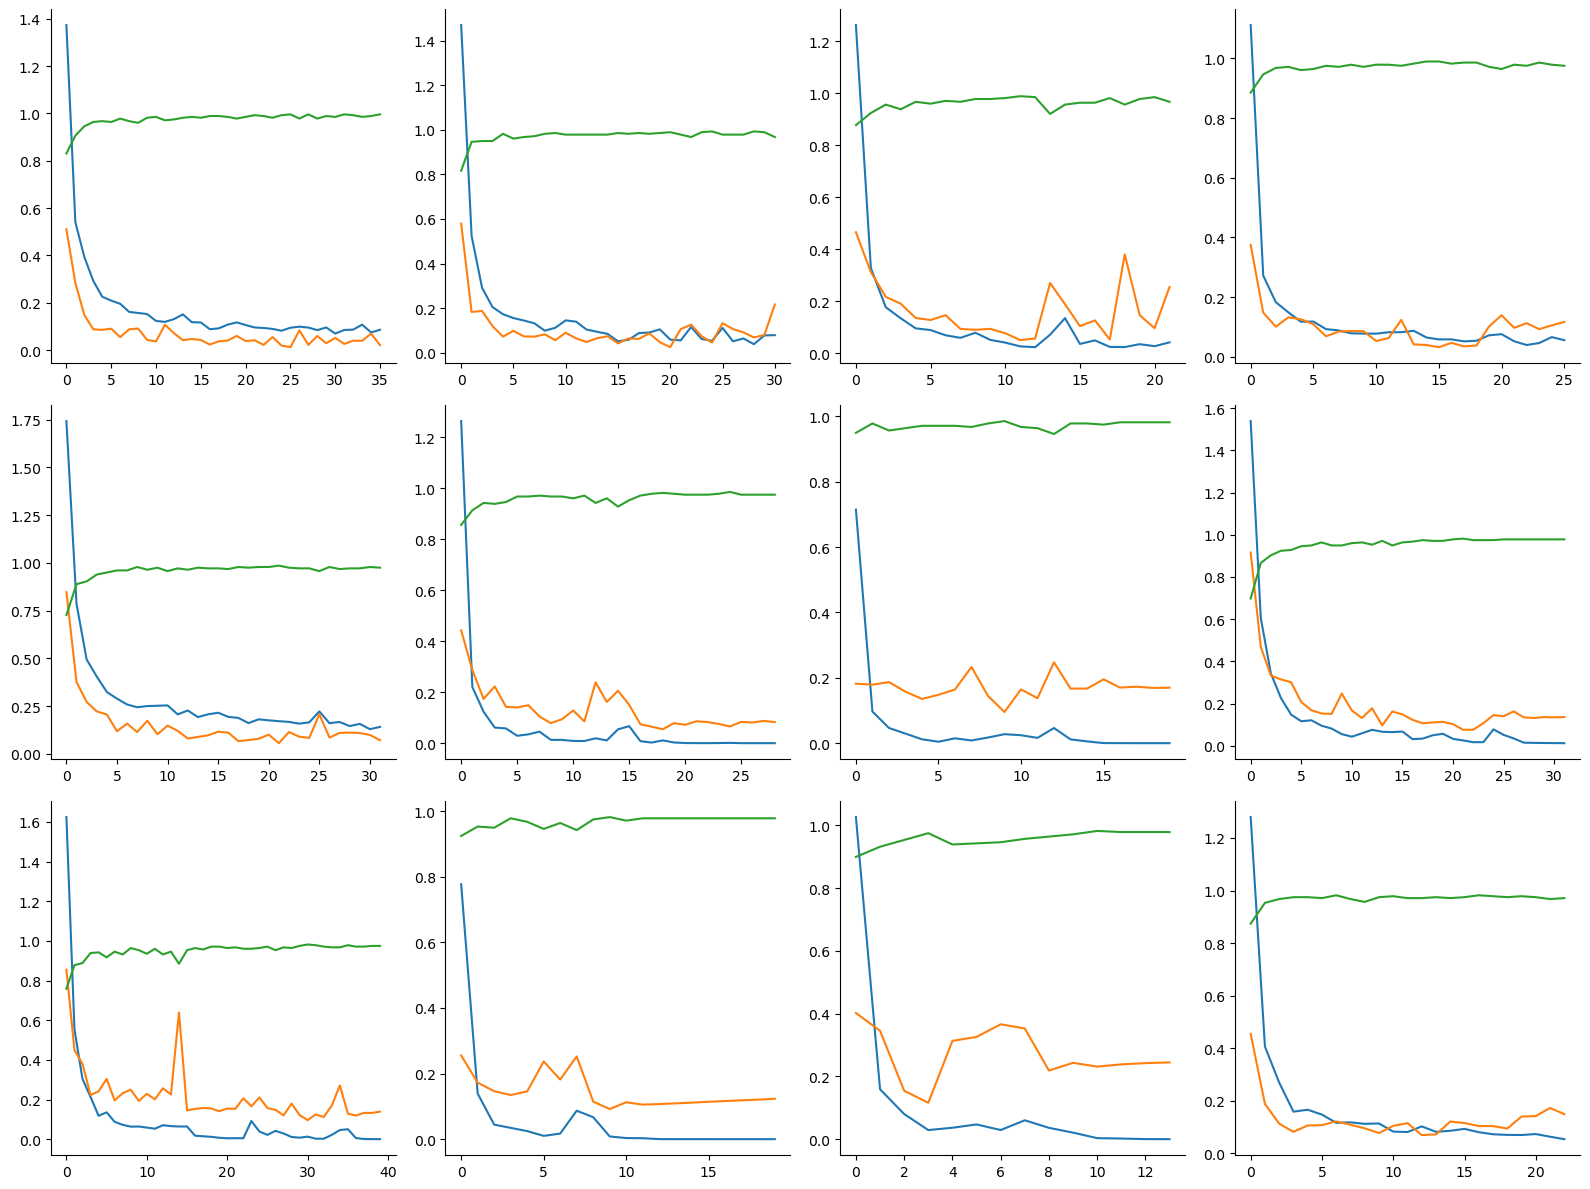

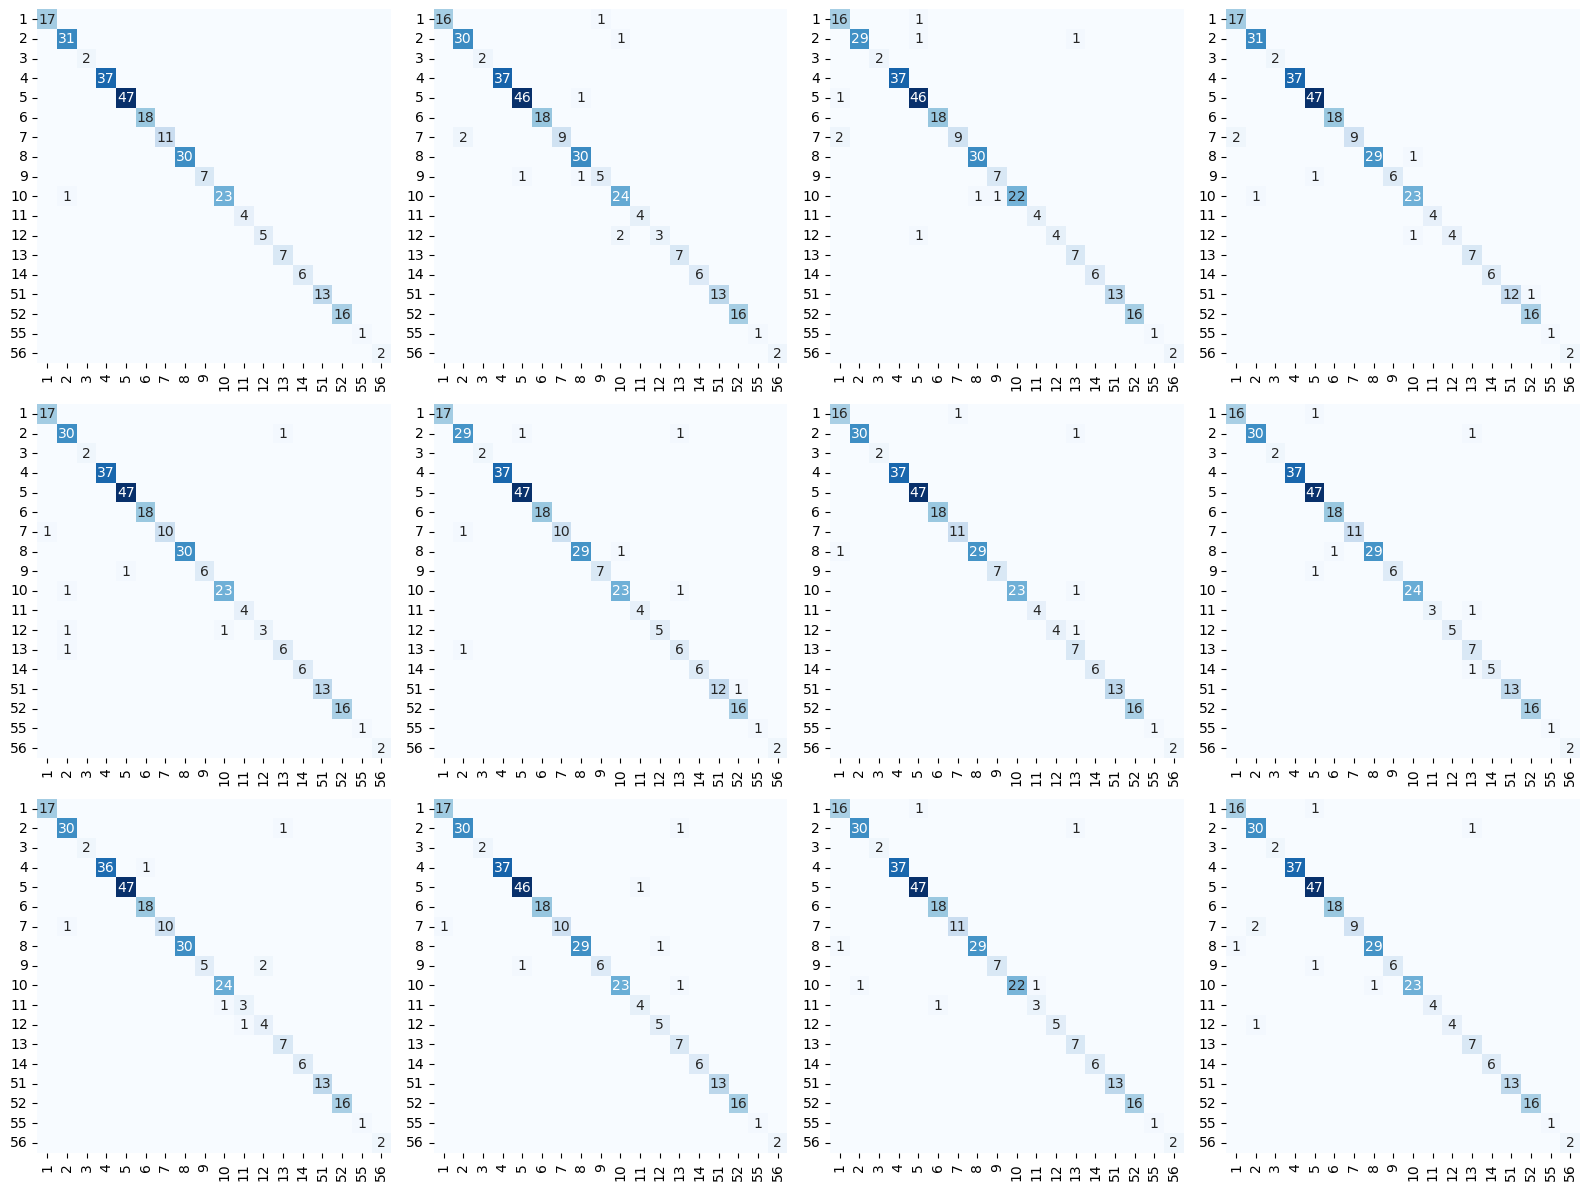

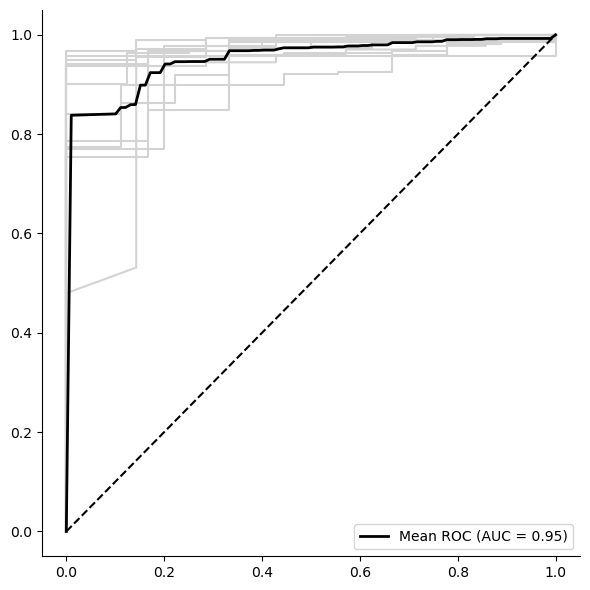

In [32]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.preprocessing import label_binarize

FAMILIES = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,51,52,55,56]
NUM_CLASSES = len(FAMILIES)

plot_result = results[:12]


figsize_per_plot = [4,4]

n = len(plot_result)
ncols = 4 
nrows = int(np.ceil(n / ncols))
figsize = (figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)

fig_curve, axes_curve = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_curve = np.array(axes_curve).reshape(-1)

fig_conf, axes_conf = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_conf = np.array(axes_conf).reshape(-1)

fig_roc, axes_roc = plt.subplots(figsize = (6,6))

# Prepare common FPR grid for averaging
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
for i, r in enumerate(plot_result):
    # Plot curves
    train_losses = np.load(os.path.join(base_dir, r['run_name'], 'train_losses.npy'))
    val_losses   = np.load(os.path.join(base_dir, r['run_name'], 'val_losses.npy'))
    val_aucs     = np.load(os.path.join(base_dir, r['run_name'], 'val_accs.npy'))
    
    # Plot roc
    val_labels = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    
    ax1 = axes_curve[i]
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses, label="Val Loss")
    ax1.plot(val_aucs, label="Val AUC")
    
    # Plot matrices
    conf = confusion_matrix(val_labels, np.argmax(val_probs, axis=1))
    # annotations = np.where(conf != 0, conf.astype(str), '')
    ax2 = axes_conf[i]
    sns.heatmap(conf, 
                annot=np.where(conf != 0, conf, ''), fmt='', # don't annotate 0 
                square=True, 
                cbar=False,
                cmap='Blues', 
                ax = ax2,
                xticklabels=FAMILIES,
                yticklabels=FAMILIES)
    
    y_true_bin = label_binarize(val_labels, classes=range(NUM_CLASSES))  # one-hot
    val_preds_class = np.argmax(val_probs, axis=1)
    y_correct = (val_preds_class == val_labels).astype(int)  # 1 if correct, 0 if incorrect
    y_score = np.max(val_probs, axis=1)  # confidence of predicted class

    fpr, tpr, _ = roc_curve(y_correct, y_score)
    roc_auc = auc(fpr, tpr)
    
    # Interpolate TPR to the mean FPR grid
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0  # ensure start at 0
    tprs.append(tpr_interp)
    aucs.append(roc_auc)
    
    axes_roc.plot(fpr, tpr, c='#D3D3D3')
    

fig_curve = pf.plt_clean_axes(fig_curve)
fig_curve.tight_layout()
fig_curve.show()

fig_conf = pf.plt_clean_axes(fig_conf)
fig_conf.tight_layout()
fig_conf.show()


# Average curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0  # ensure end at 1
mean_auc = np.mean(aucs)
axes_roc.plot(mean_fpr, mean_tpr, color='black', lw=2,
              label=f"Mean ROC (AUC = {mean_auc:.2f})")
axes_roc.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
axes_roc.legend()
fig_roc = pf.plt_clean_axes(fig_roc)
fig_roc.tight_layout()
fig_roc.show()



In [ ]:
voxel

### AA Binary model 

In [33]:
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialAA_binary/'
results = rank_models_across_runs(base_dir, slope_threshold=1e10, alpha=0.1, auc_threshold=0.60)

# Print top 5 models
for i, r in enumerate(results[:10]):
    print(f"Rank {i+1:<2}: {r['run_name']:<60} | AUC: {r['best_auc']:.4f} | ValLoss: {r['best_val_loss']:<.4} | ValLossSlope: {r['val_loss_slope']:<.4} | Epoch: {r['best_epoch']}")

Skipping test_params: missing file.
Skipping test_params_out: missing file.
Rank 1 : 20250814_121319_ptAVG_lr0.0001_bs16_hd1024_ks3_nl3_do0.3_total_sample500_pos_ratio0.5 | AUC: 0.8857 | ValLoss: 0.4195 | ValLossSlope: 0.008287 | Epoch: 10
Rank 2 : 20250814_135856_ptMAX_lr0.0005_bs32_hd512_ks3_nl3_do0.5_total_sample300_pos_ratio0.3 | AUC: 0.8823 | ValLoss: 0.7432 | ValLossSlope: 0.01844 | Epoch: 10
Rank 3 : 20250814_134634_ptMAX_lr0.01_bs16_hd512_ks1_nl1_do0.5_total_sample500_pos_ratio0.5 | AUC: 0.8766 | ValLoss: 0.457 | ValLossSlope: 0.008575 | Epoch: 4
Rank 4 : 20250814_112106_ptMAX_lr0.01_bs4_hd1024_ks1_nl2_do0.5_total_sample500_pos_ratio0.3 | AUC: 0.8884 | ValLoss: 3.046 | ValLossSlope: 0.1738 | Epoch: 22
Rank 5 : 20250814_114027_ptAVG_lr0.005_bs32_hd512_ks1_nl3_do0.2_total_sample500_pos_ratio0.5 | AUC: 0.8688 | ValLoss: 0.7931 | ValLossSlope: 0.02092 | Epoch: 21
Rank 6 : 20250814_123301_ptMAX_lr0.0001_bs16_hd1024_ks1_nl2_do0.5_total_sample500_pos_ratio0.5 | AUC: 0.8605 | ValLoss: 

In [36]:
val_probs_flat

array([2.57100672e-01, 1.30718276e-01, 2.72120535e-02, 4.96240929e-02,
       6.62587732e-02, 9.99992251e-01, 9.99111712e-01, 9.99999166e-01,
       9.99993682e-01, 9.99997258e-01, 4.12862608e-03, 7.61661667e-08,
       2.01782612e-07, 1.53541076e-03, 3.99168312e-05, 1.17862351e-06,
       3.94541621e-06, 1.85954256e-08, 2.92793811e-05, 2.68672498e-08,
       1.83613803e-02, 1.20691285e-01, 2.54546404e-01, 1.39868051e-01,
       8.78329039e-01, 9.99821961e-01, 9.99842763e-01, 9.99919772e-01,
       9.99866247e-01, 9.99643207e-01, 4.34922273e-23, 1.13457323e-27,
       2.05705688e-28, 2.58894442e-26, 4.59405921e-17, 2.63928911e-07,
       6.74671867e-07, 3.12792632e-04, 5.19718626e-04, 3.58873422e-06,
       1.47940804e-33, 2.18562560e-23, 1.65430591e-19, 3.88140859e-36,
       0.00000000e+00, 1.96198752e-11, 1.31657489e-12, 1.80367508e-08,
       3.56667799e-12, 1.15321787e-13, 2.80520394e-02, 9.72343087e-01,
       2.60362960e-02, 9.95744526e-01, 4.61952537e-01, 9.99989867e-01,
      

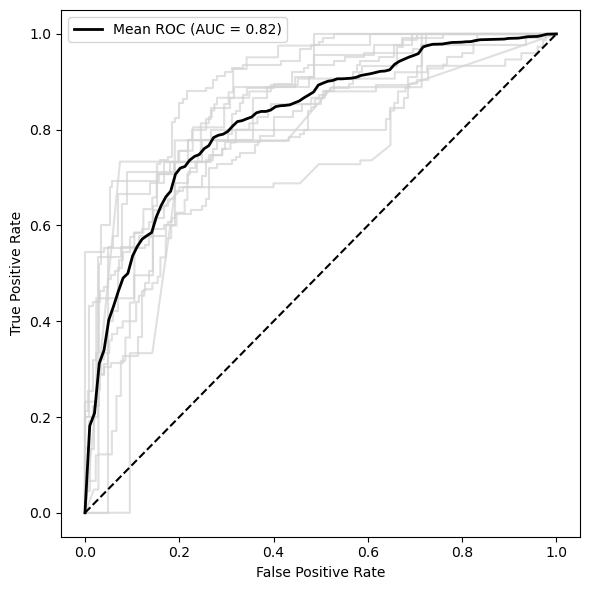

In [34]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

plot_result = results[:12]

fig_roc, axes_roc = plt.subplots(figsize = (6,6))

# Prepare common FPR grid for averaging
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

for i, r in enumerate(plot_result):
    val_labels_flat = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs_flat  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    val_auc = roc_auc_score(val_labels_flat, val_probs_flat)
    fpr, tpr, _ = roc_curve(val_labels_flat, val_probs_flat)
    
    # Interpolate TPR to the mean FPR grid
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0  # ensure start at 0
    tprs.append(tpr_interp)
    aucs.append(val_auc)
    
    axes_roc.plot(fpr, tpr, color='#D3D3D3', alpha=0.7)  # individual curves

# Average curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0  # ensure end at 1
mean_auc = np.mean(aucs)

axes_roc.plot(mean_fpr, mean_tpr, color='black', lw=2,
              label=f"Mean ROC (AUC = {mean_auc:.2f})")

# Reference line
axes_roc.plot([0, 1], [0, 1], 'k--')

axes_roc.set_xlabel('False Positive Rate')
axes_roc.set_ylabel('True Positive Rate')
axes_roc.legend()
fig_roc.tight_layout()
plt.show()



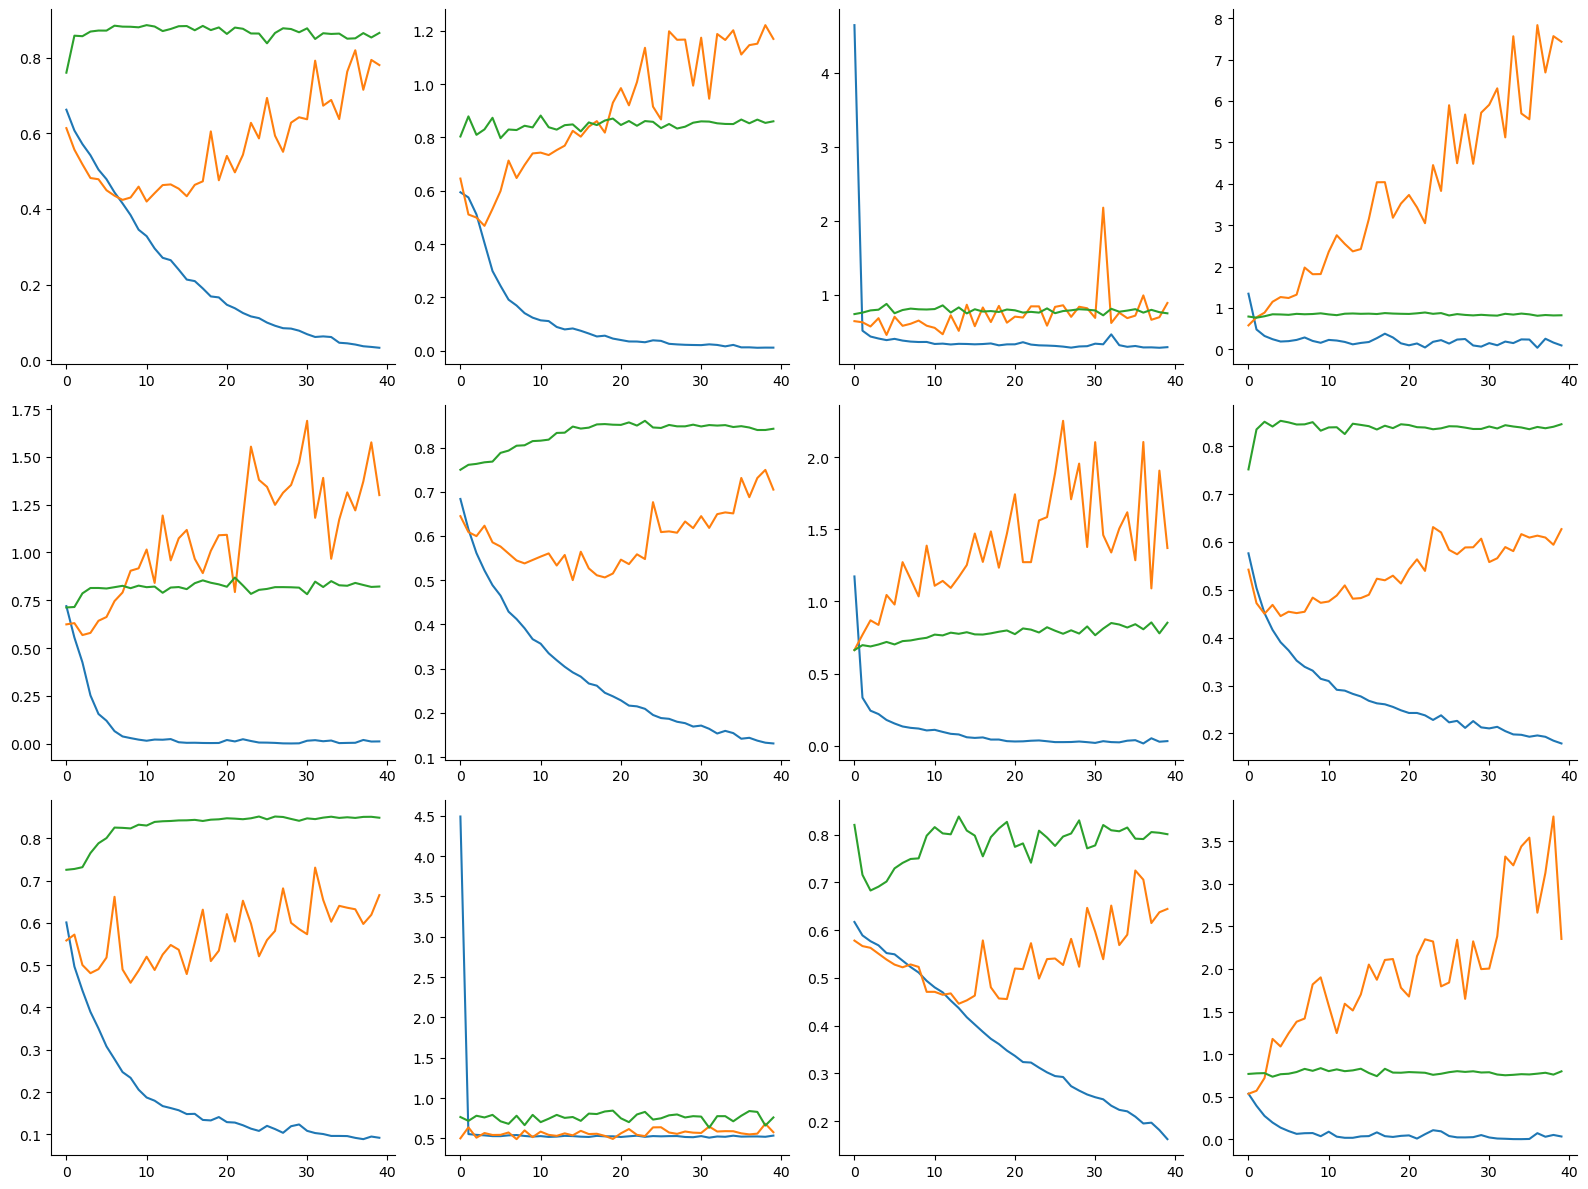

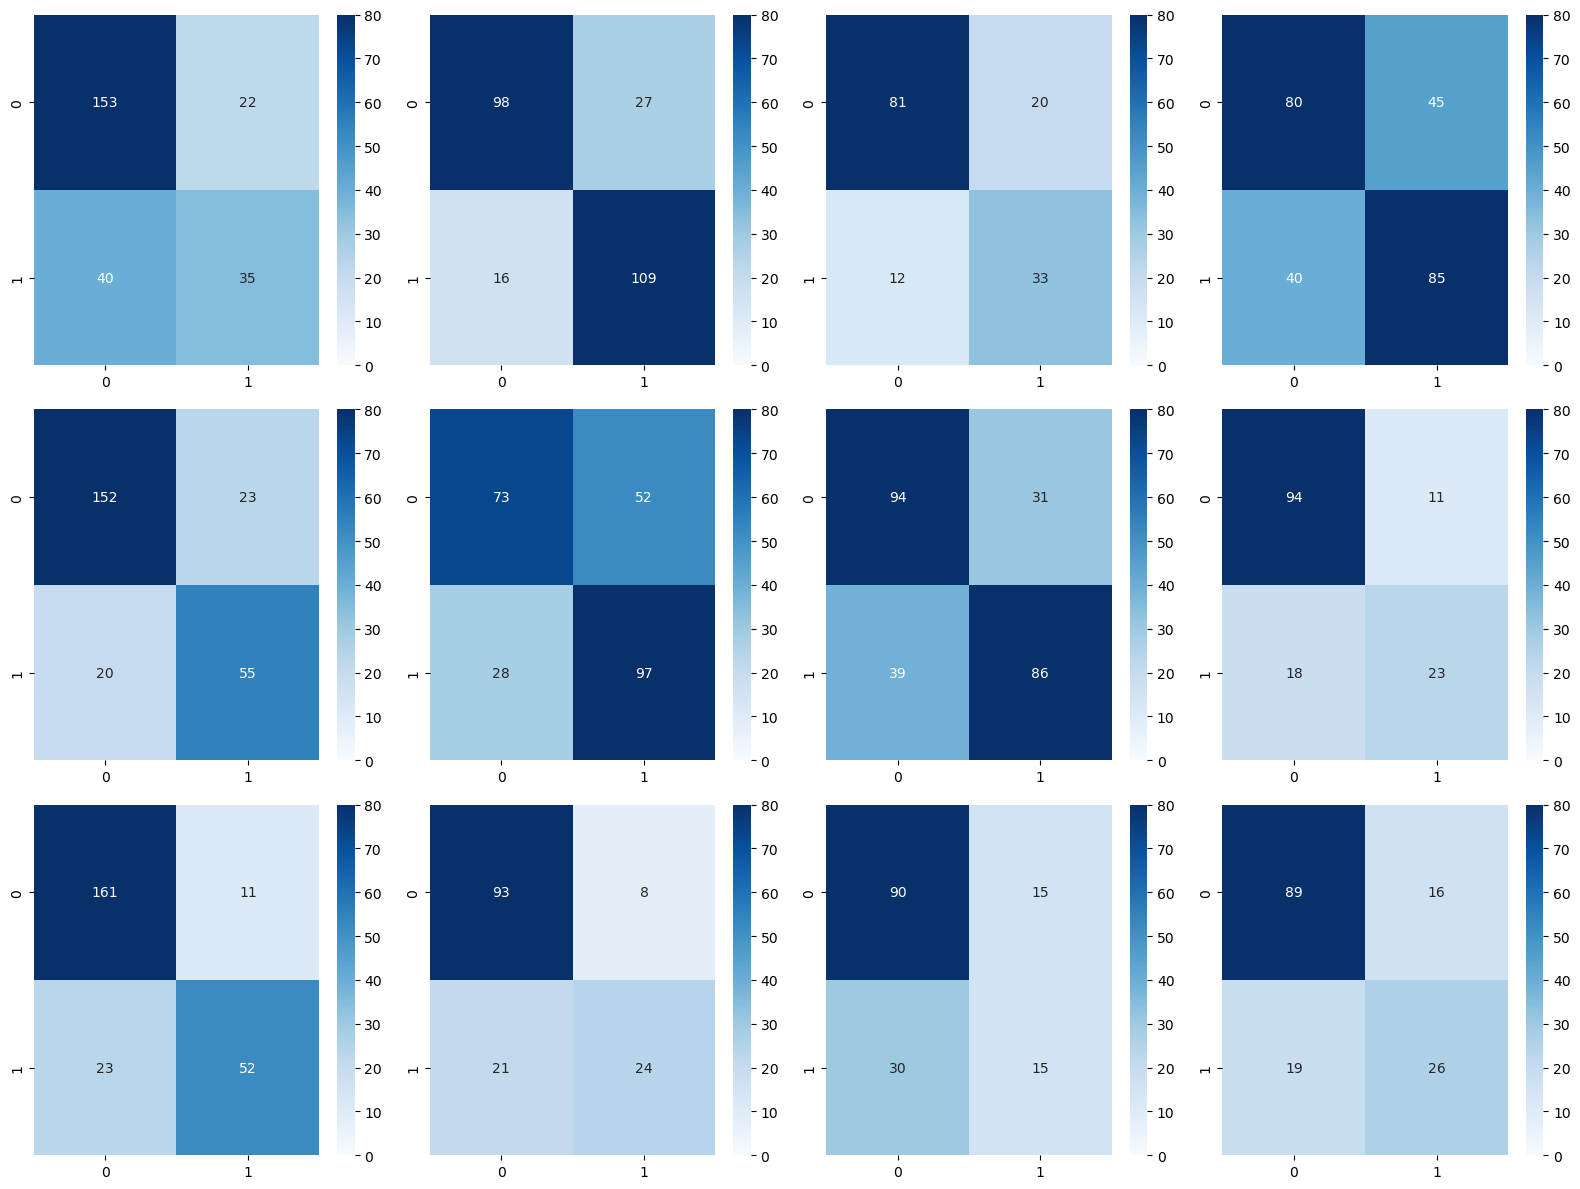

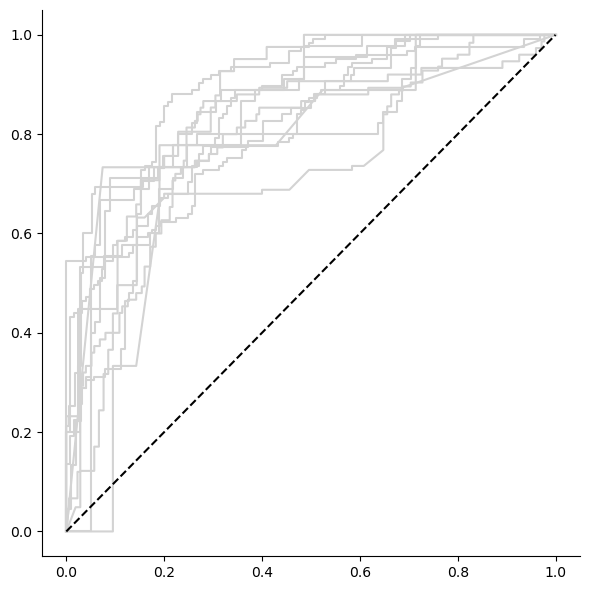

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

plot_result = results[:12]


figsize_per_plot = [4,4]

n = len(plot_result)
ncols = 4 
nrows = int(np.ceil(n / ncols))
figsize = (figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)

fig_curve, axes_curve = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_curve = np.array(axes_curve).reshape(-1)

fig_conf, axes_conf = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_conf = np.array(axes_conf).reshape(-1)

fig_roc, axes_roc = plt.subplots(figsize = (6,6))


for i, r in enumerate(plot_result):
    # Plot curves
    train_losses = np.load(os.path.join(base_dir, r['run_name'], 'train_losses.npy'))
    val_losses   = np.load(os.path.join(base_dir, r['run_name'], 'val_losses.npy'))
    val_aucs     = np.load(os.path.join(base_dir, r['run_name'], 'val_aucs.npy'))
    
    ax1 = axes_curve[i]
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses, label="Val Loss")
    ax1.plot(val_aucs, label="Val AUC")
    
    # Plot matrices
    conf = confusion_matrix(val_labels_flat, (val_probs_flat > 0.5).astype(np.float32))

    ax2 = axes_conf[i]
    sns.heatmap(conf, annot=True, 
                      fmt='d', 
                      cmap='Blues',
                      vmin=0, vmax=80, 
                      ax = ax2)
    
    # Plot roc
    val_labels_flat = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs_flat  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    val_auc = roc_auc_score(val_labels_flat, val_probs_flat)
    fpr, tpr, _ = roc_curve(val_labels_flat, val_probs_flat)
    
    # ax2 = axes_roc[i]
    # axes_roc.plot(fpr, tpr, label=f"AUC = {val_auc:.2f}")
    # axes_roc.plot([0, 1], [0, 1], 'k--')
    # axes_roc.legend()
    
    axes_roc.plot(fpr, tpr, label=f"AUC = {val_auc:.2f}", c='#D3D3D3')
    

fig_curve = pf.plt_clean_axes(fig_curve)
fig_curve.tight_layout()
fig_curve.show()

fig_conf = pf.plt_clean_axes(fig_conf)
fig_conf.tight_layout()
fig_conf.show()

axes_roc.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
fig_roc = pf.plt_clean_axes(fig_roc)
fig_roc.tight_layout()
fig_roc.show()



### ESM binary model 

In [20]:
base_dir = '/mnt/data2/Justice/OR_learning/output/AF3/cnn_spatialESM_binary/param_sweep/'
results = rank_models_across_runs(base_dir, slope_threshold=np.inf, alpha=0.1, auc_threshold=0.60)

# Print top 5 models
for i, r in enumerate(results[:10]):
    print(f"Rank {i+1:<2}: {r['run_name']:<60} | AUC: {r['best_auc']:.4f} | ValLoss: {r['best_val_loss']:<.4} | ValLossSlope: {r['val_loss_slope']:<.4} | Epoch: {r['best_epoch']}")

Skipping 20250820_100226_ptMAX_lr0.01_bs32_hd256_ks5_nl4_do0.2_total_sample2000_pos_ratio0.3: missing file.
Rank 1 : 20250818_230830_ptAVG_lr0.0005_bs4_hd64_ks1_nl4_do0.0_total_sample1000_pos_ratio0.3 | AUC: 0.9293 | ValLoss: 0.5388 | ValLossSlope: 0.004124 | Epoch: 38
Rank 2 : 20250819_140040_ptAVG_lr0.005_bs16_hd512_ks1_nl4_do0.2_total_sample1000_pos_ratio0.5 | AUC: 0.9016 | ValLoss: 0.941 | ValLossSlope: 0.02052 | Epoch: 35
Rank 3 : 20250820_082254_ptAVG_lr0.0001_bs4_hd512_ks3_nl4_do0.5_total_sample1000_pos_ratio0.3 | AUC: 0.8922 | ValLoss: 0.6768 | ValLossSlope: 0.01327 | Epoch: 25
Rank 4 : 20250819_012858_ptAVG_lr0.0005_bs4_hd256_ks5_nl4_do0.0_total_sample1000_pos_ratio0.5 | AUC: 0.8705 | ValLoss: 1.116 | ValLossSlope: 0.02608 | Epoch: 14
Rank 5 : 20250818_172318_ptAVG_lr0.001_bs4_hd256_ks5_nl4_do0.5_total_sample1000_pos_ratio0.5 | AUC: 0.8702 | ValLoss: 1.189 | ValLossSlope: 0.03473 | Epoch: 19
Rank 6 : 20250819_081759_ptMAX_lr0.0005_bs4_hd128_ks1_nl1_do0.5_total_sample1000_pos_r

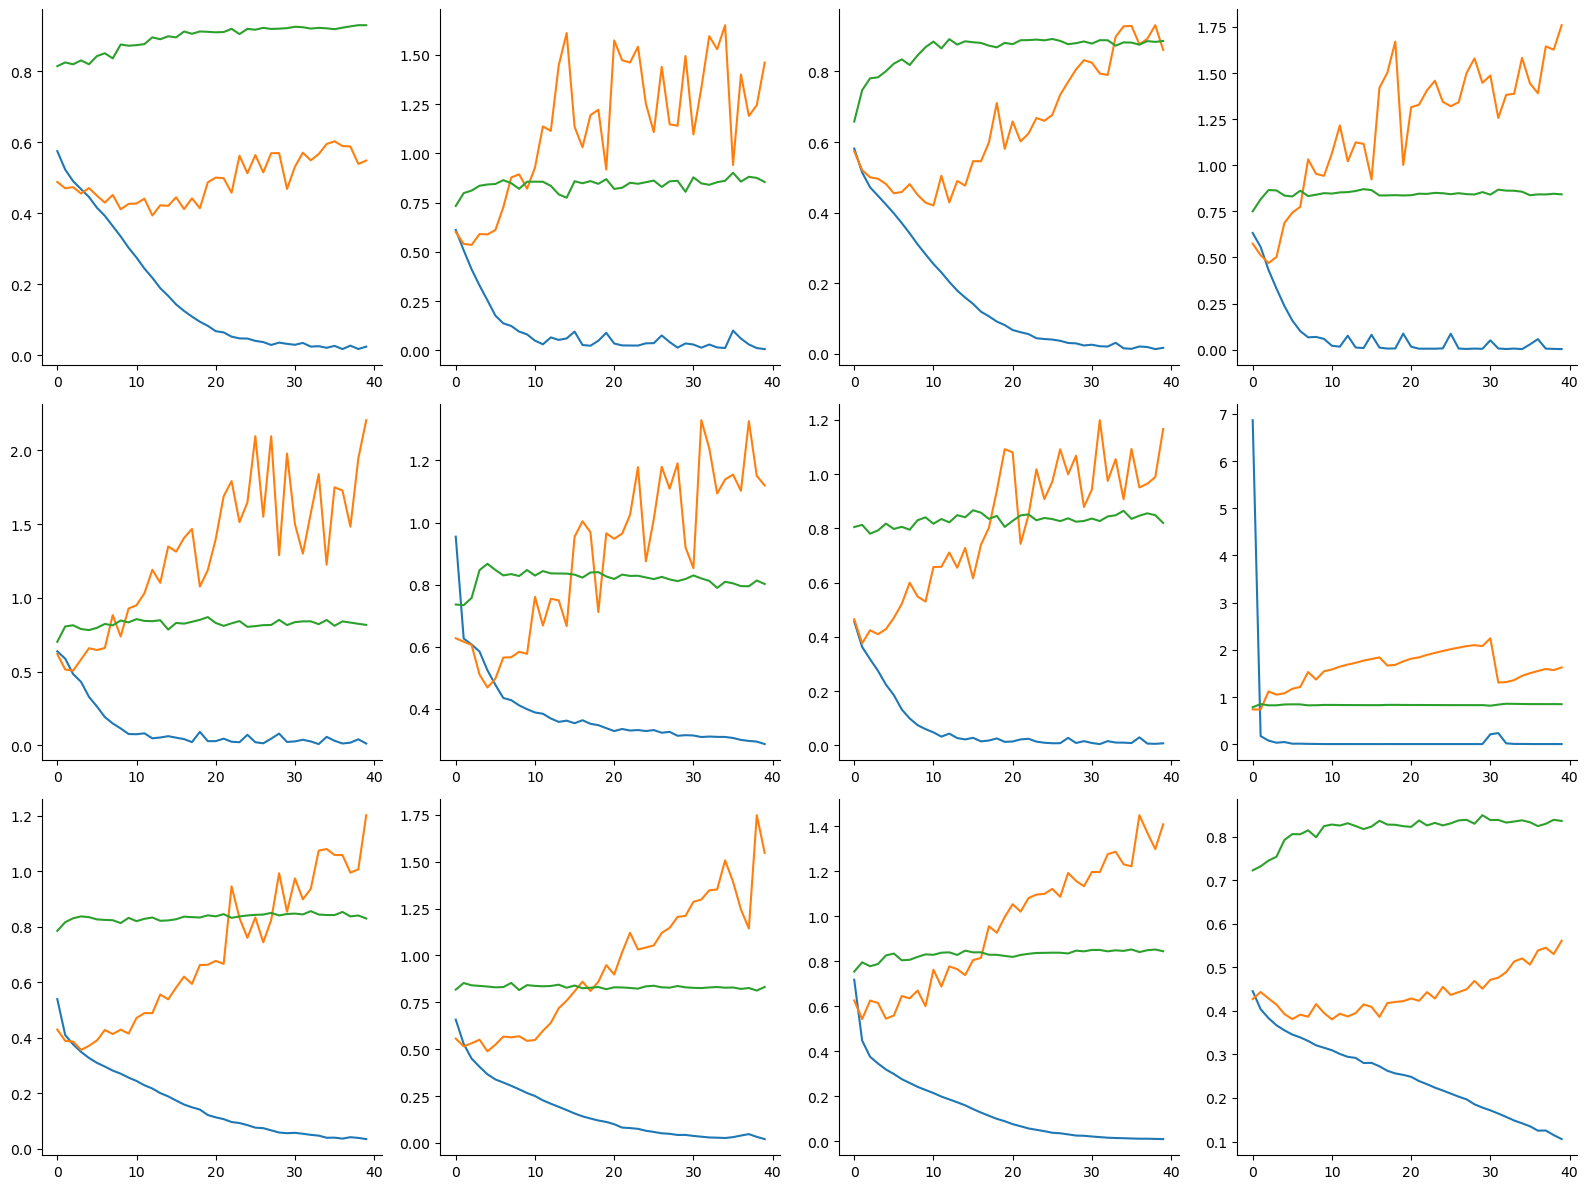

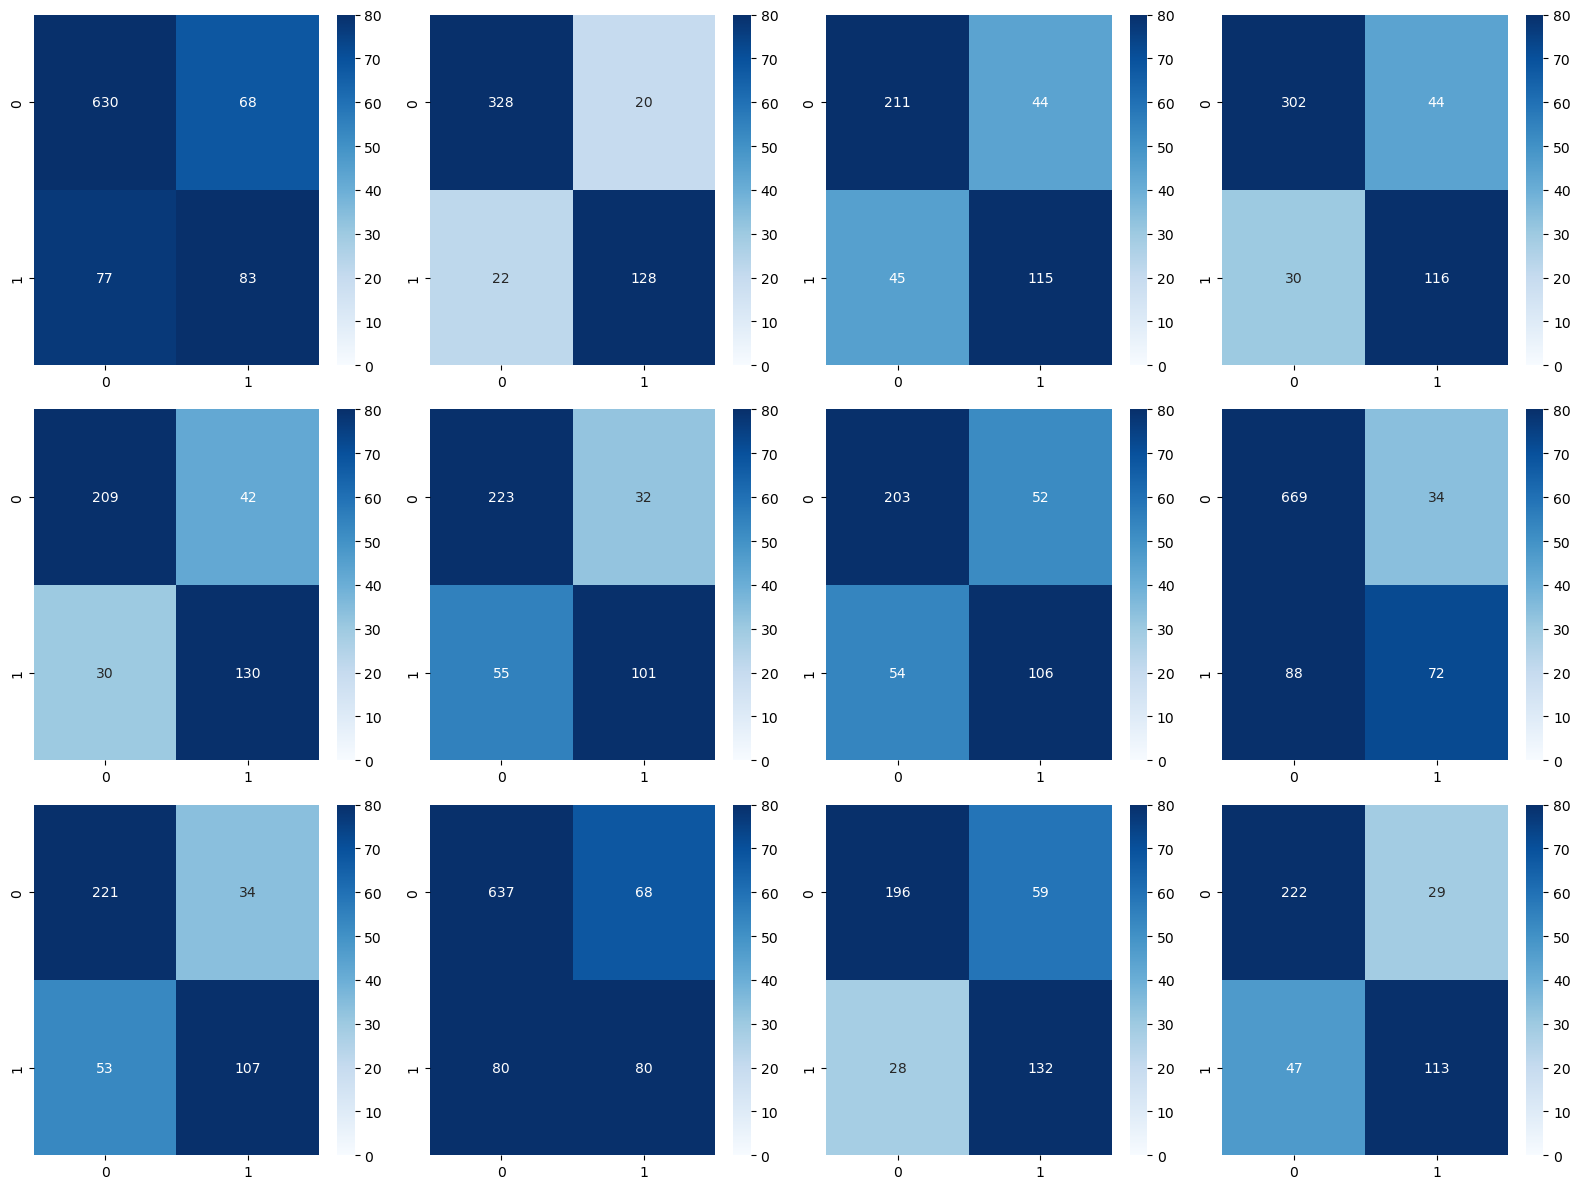

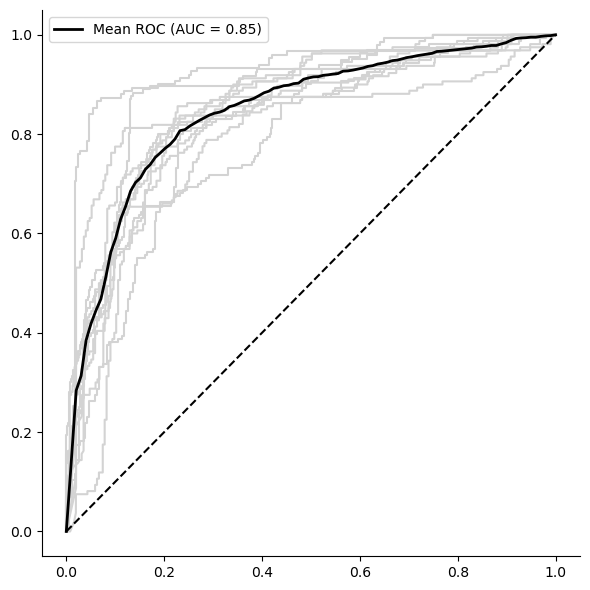

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

plot_result = results[:12]


figsize_per_plot = [4,4]

n = len(plot_result)
ncols = 4 
nrows = int(np.ceil(n / ncols))
figsize = (figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)

fig_curve, axes_curve = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_curve = np.array(axes_curve).reshape(-1)

fig_conf, axes_conf = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axes_conf = np.array(axes_conf).reshape(-1)

fig_roc, axes_roc = plt.subplots(figsize = (6,6))

# Prepare common FPR grid for averaging
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
for i, r in enumerate(plot_result):
    # Plot curves
    train_losses = np.load(os.path.join(base_dir, r['run_name'], 'train_losses.npy'))
    val_losses   = np.load(os.path.join(base_dir, r['run_name'], 'val_losses.npy'))
    val_aucs     = np.load(os.path.join(base_dir, r['run_name'], 'val_aucs.npy'))
    
    ax1 = axes_curve[i]
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses, label="Val Loss")
    ax1.plot(val_aucs, label="Val AUC")
    
    # Plot matrices
    conf = confusion_matrix(val_labels_flat, (val_probs_flat > 0.5).astype(np.float32))

    ax2 = axes_conf[i]
    sns.heatmap(conf, annot=True, 
                      fmt='d', 
                      cmap='Blues',
                      vmin=0, vmax=80, 
                      ax = ax2)
    
    # Plot roc
    val_labels_flat = np.load(os.path.join(base_dir, r['run_name'], 'val_labels.npy'))
    val_probs_flat  = np.load(os.path.join(base_dir, r['run_name'], 'val_probs.npy'))
    
    val_auc = roc_auc_score(val_labels_flat, val_probs_flat)
    fpr, tpr, _ = roc_curve(val_labels_flat, val_probs_flat)
    
    # Interpolate TPR to the mean FPR grid
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0  # ensure start at 0
    tprs.append(tpr_interp)
    aucs.append(val_auc)
    axes_roc.plot(fpr, tpr, 
                #   label=f"AUC = {val_auc:.2f}",
                  c='#D3D3D3')


# Average curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0  # ensure end at 1
mean_auc = np.mean(aucs)
axes_roc.plot(mean_fpr, mean_tpr, color='black', lw=2,
              label=f"Mean ROC (AUC = {mean_auc:.2f})")
    

fig_curve = pf.plt_clean_axes(fig_curve)
fig_curve.tight_layout()
fig_curve.show()

fig_conf = pf.plt_clean_axes(fig_conf)
fig_conf.tight_layout()
fig_conf.show()

axes_roc.plot([0, 1], [0, 1], 'k--') # Add diagonal line 
axes_roc.legend()
fig_roc = pf.plt_clean_axes(fig_roc)
fig_roc.tight_layout()
fig_roc.show()

